In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay,
                             f1_score, precision_score, recall_score)

print("All imports successful ✅")

All imports successful ✅


## 1. Download Data

In [3]:
df = yf.download("UCOBANK.NS", start="2010-01-01", end="2025-12-31", auto_adjust=False)
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

nifty_bank = yf.download("^NSEBANK", start="2010-01-01", end="2025-12-31", auto_adjust=True)
nifty_bank.columns = [col[0] if isinstance(col, tuple) else col for col in nifty_bank.columns]
nifty_bank.index = pd.to_datetime(nifty_bank.index)

print("Raw data shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Nifty Bank shape:", nifty_bank.shape)
df.tail(3)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Raw data shape: (3948, 6)
Columns: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
Nifty Bank shape: (3943, 5)


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-12-26,28.159779,28.629999,29.00,28.540001,28.790001,4361450
2025-12-29,28.041750,28.510000,28.84,28.410000,28.540001,3865980
2025-12-30,28.356495,28.830000,28.99,28.290001,28.549999,7011814


## 2. Target Variable

In [4]:
# Target: will TOMORROW's close be higher than TODAY's?
# FORWARD-LOOKING label — index date T predicts T+1
df['Target_Return_Fwd'] = (df['Adj Close'].shift(-1) > df['Adj Close']).astype(int)

# Store next-day return magnitude for human-readable verification
df['NextDay_Return_%'] = df['Adj Close'].shift(-1) / df['Adj Close'] - 1

up   = df['Target_Return_Fwd'].sum()
down = len(df['Target_Return_Fwd']) - up
print(f"Up days : {up}  ({up/len(df)*100:.1f}%)")
print(f"Down days: {down} ({down/len(df)*100:.1f}%)")

Up days : 1727  (43.7%)
Down days: 2221 (56.3%)


## 3. Feature Engineering

In [5]:
# ── Returns & Price features ──────────────────────────────────────────────────
# BACKWARD-LOOKING: today's close vs yesterday's close
# Do NOT use this as a proxy for Target_Return_Fwd in accuracy checks
df['Daily_Return_%'] = df['Adj Close'].pct_change() * 100
df['Daily_Range']    = df['High'] - df['Low']
df['Price_change']   = df['Adj Close'] - df['Open']

# ── Moving Averages ───────────────────────────────────────────────────────────
df['MA20']  = df['Adj Close'].rolling(20).mean()
df['MA50']  = df['Adj Close'].rolling(50).mean()
df['MA200'] = df['Adj Close'].rolling(200).mean()

# ── MACD ──────────────────────────────────────────────────────────────────────
df['EMA12']     = df['Adj Close'].ewm(span=12, adjust=False).mean()
df['EMA26']     = df['Adj Close'].ewm(span=26, adjust=False).mean()
df['MACD']      = df['EMA12'] - df['EMA26']
df['Signal']    = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_Hist'] = df['MACD'] - df['Signal']

# ── RSI (14-day) ──────────────────────────────────────────────────────────────
delta    = df['Adj Close'].diff()
gain     = delta.where(delta > 0, 0)
loss     = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs       = avg_gain / avg_loss
df['RSI']      = 100 - (100 / (1 + rs))
df['RSI_norm'] = df['RSI'] / 100

# ── Bollinger Bands ───────────────────────────────────────────────────────────
df['STD20'] = df['Adj Close'].rolling(20).std()
df['Upper'] = df['MA20'] + 2 * df['STD20']
df['Lower'] = df['MA20'] - 2 * df['STD20']
df['BB_pct'] = (df['Adj Close'] - df['Lower']) / (df['Upper'] - df['Lower'])

# ── ATR (14-day) ──────────────────────────────────────────────────────────────
df['TR']    = np.maximum(
                  df['High'] - df['Low'],
                  np.maximum(abs(df['High'] - df['Adj Close'].shift(1)),
                             abs(df['Low']  - df['Adj Close'].shift(1))))
df['ATR14'] = df['TR'].rolling(14).mean()

# ── Volume ────────────────────────────────────────────────────────────────────
df['Volume_Ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()

# ── MA Cross Signals ──────────────────────────────────────────────────────────
df['MA20_above_MA50']   = (df['MA20'] > df['MA50']).astype(int)
df['Price_above_MA50']  = (df['Adj Close'] > df['MA50']).astype(int)
df['Price_above_MA200'] = (df['Adj Close'] > df['MA200']).astype(int)

# ── Lag Features ─────────────────────────────────────────────────────────────
for lag in [1, 2, 3, 5]:
    df[f'RSI_Lag{lag}']    = df['RSI'].shift(lag)
    df[f'Return_Lag{lag}'] = df['Daily_Return_%'].shift(lag)
    df[f'MACD_Lag{lag}']   = df['MACD'].shift(lag)
    df[f'Volume_Lag{lag}'] = df['Volume'].shift(lag)

# ── Calendar Feature ──────────────────────────────────────────────────────────
df['DayOfWeek'] = (df.index.get_level_values(0).dayofweek
                   if isinstance(df.index, pd.MultiIndex)
                   else pd.to_datetime(df.index).dayofweek)

# ── Nifty Bank Index Features ─────────────────────────────────────────────────
nb_close = nifty_bank['Close'].reindex(df.index).ffill()
df['NiftyBank_Return'] = nb_close.pct_change() * 100
df['NiftyBank_Lag1']   = df['NiftyBank_Return'].shift(1)
df['NiftyBank_MA5']    = nb_close.rolling(5).mean()
df['NiftyBank_MA20']   = nb_close.rolling(20).mean()
df['NiftyBank_Trend']  = (df['NiftyBank_MA5'] > df['NiftyBank_MA20']).astype(int)
df['UCO_vs_NiftyBank'] = df['Daily_Return_%'] - df['NiftyBank_Return']

print("Feature engineering done ✅")
print(f"DataFrame shape: {df.shape}")

Feature engineering done ✅
DataFrame shape: (3948, 54)


## Change 1 — Stationary OBV, PVT and Rolling VWAP

### What was changed and why

**Old code (cumulative — broken):**
```python
# On-Balance Volume (OBV)
df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).fillna(0).cumsum()
# Price-Volume Trend (PVT)
df['PVT'] = ((df['Close'].pct_change() * df['Volume'])).fillna(0).cumsum()
# VWAP (cumulative since 2010)
tp = (df['High'] + df['Low'] + df['Close']) / 3
df['VWAP'] = (df['Volume'] * tp).cumsum() / df['Volume'].cumsum()
```

**Problems with the old approach:**
1. `OBV` and `PVT` are unbounded cumulative sums that grow monotonically since 2010.
   By 2024 the values are orders of magnitude larger than in 2010, so the model
   trained on 2010–2019 sees completely out-of-distribution values in the test set.
2. Cumulative VWAP computed since 2010 is essentially just the average price over
   15 years — it carries no intraday or swing signal by 2024.

**Fix:**
- Replace `OBV` and `PVT` with their 20-day rate-of-change (stationary, bounded)
- Replace cumulative `VWAP` with a 20-day rolling VWAP (resets every 20 days)

In [6]:
def add_banking_indicators(df):
    # --- 1. Intensity & Momentum ---
    df['Vol_SMA_Ratio'] = df['Volume'] / df['Volume'].rolling(window=5).mean().replace(0, np.nan)
    df['Vol_SMA_Ratio'] = df['Vol_SMA_Ratio'].fillna(1)
    df['Vol_Momentum']  = df['Volume'].pct_change()
    df['Vol_Shock']     = (df['Volume'] > (df['Volume'].rolling(window=10).mean() * 2)).astype(int)

    # --- 2. Trend Confirmation (STATIONARY versions) --------------------------
    # OBV rate-of-change over 20 days — stationary, no regime drift
    obv_raw      = (np.sign(df['Close'].diff()) * df['Volume']).fillna(0).cumsum()
    df['OBV_ROC'] = obv_raw.pct_change(20)   # replaces raw cumulative OBV

    # PVT rate-of-change over 20 days — stationary, no regime drift
    pvt_raw      = (df['Close'].pct_change() * df['Volume']).fillna(0).cumsum()
    df['PVT_ROC'] = pvt_raw.pct_change(20)   # replaces raw cumulative PVT

    # --- 3. Institutional Benchmarks (ROLLING VWAP) ---------------------------
    # 20-day rolling VWAP — resets context every 20 bars, meaningful signal
    tp           = (df['High'] + df['Low'] + df['Close']) / 3
    vwap_window  = 20
    df['VWAP']       = ((df['Volume'] * tp).rolling(vwap_window).sum() /
                         df['Volume'].rolling(vwap_window).sum())
    df['VWAP_Ratio'] = df['Close'] / df['VWAP']

    # --- 4. Liquidity & Flow ---
    pos_flow = np.where(tp > tp.shift(1), tp * df['Volume'], 0)
    neg_flow = np.where(tp < tp.shift(1), tp * df['Volume'], 0)
    mfr      = pd.Series(pos_flow).rolling(14).sum() / pd.Series(neg_flow).rolling(14).sum()
    df['MFI'] = 100 - (100 / (1 + mfr))

    mfv      = (((df['Close'] - df['Low']) - (df['High'] - df['Close'])) /
                 (df['High'] - df['Low'])) * df['Volume']
    df['CMF'] = mfv.rolling(20).sum() / df['Volume'].rolling(20).sum()

    return df.fillna(0)

df = add_banking_indicators(df)
print("Banking indicators added ✅  (OBV_ROC, PVT_ROC, rolling VWAP)")

Banking indicators added ✅  (OBV_ROC, PVT_ROC, rolling VWAP)


In [7]:
def wilders_ema(series, period):
    """Proper Wilder's smoothing — EMA with alpha = 1/period."""
    return series.ewm(alpha=1/period, adjust=False).mean()

def add_adx_features(df, period=14):
    """ADX, +DI, -DI using correct Wilder's EMA smoothing."""
    df = df.copy()
    df['tr1'] = df['High'] - df['Low']
    df['tr2'] = abs(df['High'] - df['Close'].shift(1))
    df['tr3'] = abs(df['Low']  - df['Close'].shift(1))
    df['TR']  = df[['tr1','tr2','tr3']].max(axis=1)

    df['up_move']   = df['High'] - df['High'].shift(1)
    df['down_move'] = df['Low'].shift(1) - df['Low']
    df['+DM'] = np.where((df['up_move'] > df['down_move']) & (df['up_move'] > 0),   df['up_move'],   0)
    df['-DM'] = np.where((df['down_move'] > df['up_move']) & (df['down_move'] > 0), df['down_move'], 0)

    df['TR_s']  = wilders_ema(df['TR'],   period)
    df['+DM_s'] = wilders_ema(df['+DM'],  period)
    df['-DM_s'] = wilders_ema(df['-DM'],  period)

    df['+DI'] = 100 * (df['+DM_s'] / df['TR_s'])
    df['-DI'] = 100 * (df['-DM_s'] / df['TR_s'])
    df['DX']  = 100 * (abs(df['+DI'] - df['-DI']) / (df['+DI'] + df['-DI']))
    df['ADX'] = wilders_ema(df['DX'], period)

    cols_to_drop = ['tr1','tr2','tr3','TR','up_move','down_move','TR_s','+DM_s','-DM_s','DX']
    return df.drop(columns=cols_to_drop).dropna()

df = add_adx_features(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3947 entries, 2010-01-05 to 2025-12-30
Data columns (total 67 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Adj Close          3947 non-null   float64
 1   Close              3947 non-null   float64
 2   High               3947 non-null   float64
 3   Low                3947 non-null   float64
 4   Open               3947 non-null   float64
 5   Volume             3947 non-null   int64  
 6   Target_Return_Fwd  3947 non-null   int64  
 7   NextDay_Return_%   3947 non-null   float64
 8   Daily_Return_%     3947 non-null   float64
 9   Daily_Range        3947 non-null   float64
 10  Price_change       3947 non-null   float64
 11  MA20               3947 non-null   float64
 12  MA50               3947 non-null   float64
 13  MA200              3947 non-null   float64
 14  EMA12              3947 non-null   float64
 15  EMA26              3947 non-null   float64
 16  MACD  

## 4. Clean & Split

In [8]:
df = df.dropna(subset=['Target_Return_Fwd'])
first_valid = df.dropna().index[0]
df = df.loc[first_valid:].copy()
df = df.ffill().bfill()
df.index = pd.to_datetime(df.index)

print(f"Clean data: {df.shape[0]} rows  |  {df.index.min().date()} → {df.index.max().date()}")
print("Nulls remaining:", df.isnull().sum().sum())

Clean data: 3947 rows  |  2010-01-05 → 2025-12-30
Nulls remaining: 0


In [9]:
feature_cols = [
    # Core price/volume
    'Daily_Return_%', 'Daily_Range', 'Price_change',
    # Trend
    'MA50', 'MA200', 'MA20_above_MA50', 'Price_above_MA50', 'Price_above_MA200',
    # Momentum
    'MACD', 'Signal', 'MACD_Hist',
    'RSI', 'RSI_norm',
    # Volatility
    'STD20', 'BB_pct', 'ATR14',
    # Volume
    'Volume_Ratio',
    # Lags: RSI
    'RSI_Lag1', 'RSI_Lag2', 'RSI_Lag3', 'RSI_Lag5',
    # Lags: Return
    'Return_Lag1', 'Return_Lag2', 'Return_Lag3', 'Return_Lag5',
    # Lags: MACD
    'MACD_Lag1', 'MACD_Lag2', 'MACD_Lag3', 'MACD_Lag5',
    # Lags: Volume
    'Volume_Lag1', 'Volume_Lag2', 'Volume_Lag3', 'Volume_Lag5',
    # Calendar
    'DayOfWeek',
    # Nifty Bank sector features (NiftyBank_Return removed — same-day, not safe)
    'NiftyBank_Lag1',
    'NiftyBank_Trend',
    'UCO_vs_NiftyBank',
    # Volume intensity
    'Vol_SMA_Ratio', 'Vol_Momentum', 'Vol_Shock',
    # Trend confirmation — STATIONARY rate-of-change versions
    'PVT_ROC', 'OBV_ROC',
    # Institutional benchmarks — rolling VWAP
    'VWAP', 'VWAP_Ratio',
    # Liquidity & flow
    'MFI', 'CMF',
    'ADX', '+DI', '-DI',
]

missing = [col for col in feature_cols if col not in df.columns]
print(f"Missing columns: {missing}")
print(f"Total features: {len(feature_cols)}")

Missing columns: []
Total features: 49


## Change 2 — Three-Way Temporal Split for Honest Threshold Tuning

### What was changed and why

**Old code (two-way split — broken):**
```python
X_train = df[(df.index.year >= 2010) & (df.index.year <= 2021)][feature_cols]
y_train = df[(df.index.year >= 2010) & (df.index.year <= 2021)]['Target_Return']

X_test  = df[(df.index.year >= 2022) & (df.index.year <= 2025)][feature_cols]
y_test  = df[(df.index.year >= 2022) & (df.index.year <= 2025)]['Target_Return']
```
And then threshold was tuned on X_test:
```python
y_proba = best_rf.predict_proba(X_test_reduced)[:, 1]
for t in thresholds:
    acc = accuracy_score(y_test, preds)   # ← peeking at test set
```

**Problem:** The threshold is chosen by maximising accuracy on the test set, then
performance is reported on that same test set. This is test-set contamination —
the model has seen the test set twice. Reported accuracy is inflated.

**Fix — Three-way split:**
```
TRAIN      2010–2019  →  model learns RF weights
VALIDATION 2020–2021  →  threshold is tuned here (model never trained on this)
TEST       2022–2025  →  touched exactly once at the very end
```

In [10]:
# ── Three-way temporal split ──────────────────────────────────────────────────
X_train = df[(df.index.year >= 2010) & (df.index.year <= 2019)][feature_cols]
y_train = df[(df.index.year >= 2010) & (df.index.year <= 2019)]['Target_Return_Fwd']

# VALIDATION: used ONLY for threshold tuning — model never trains on this
X_val   = df[(df.index.year >= 2020) & (df.index.year <= 2021)][feature_cols]
y_val   = df[(df.index.year >= 2020) & (df.index.year <= 2021)]['Target_Return_Fwd']

# TEST: touched exactly once — never used for any decision before final eval
X_test  = df[(df.index.year >= 2022) & (df.index.year <= 2025)][feature_cols]
y_test  = df[(df.index.year >= 2022) & (df.index.year <= 2025)]['Target_Return_Fwd']

print(f"Train      : {X_train.index.min().date()} → {X_train.index.max().date()}  ({len(X_train)} rows)")
print(f"Validation : {X_val.index.min().date()}   → {X_val.index.max().date()}    ({len(X_val)} rows)")
print(f"Test       : {X_test.index.min().date()}  → {X_test.index.max().date()}   ({len(X_test)} rows)")

Train      : 2010-01-05 → 2019-12-31  (2461 rows)
Validation : 2020-01-01   → 2021-12-31    (499 rows)
Test       : 2022-01-03  → 2025-12-30   (987 rows)


In [11]:
features_to_remove = [
    'MA50',       # Redundant with EMA
    'ADX', '+DI', # Only -DI proved significant in RFE
    'RSI',        # Low informational value for this stock
    'Signal',     # Redundant with MACD_Hist
]

# Apply to all three splits
X_train_reduced = X_train.drop(columns=features_to_remove)
X_val_reduced   = X_val.drop(columns=features_to_remove)
X_test_reduced  = X_test.drop(columns=features_to_remove)

print(f"Features removed : {len(features_to_remove)}")
print(f"Remaining        : {X_train_reduced.shape[1]}")

Features removed : 5
Remaining        : 44


## 5. Feature Selection with RFE

In [12]:
# Clean all three splits identically
for name, Xs in [('X_train_reduced', X_train_reduced),
                  ('X_val_reduced',   X_val_reduced),
                  ('X_test_reduced',  X_test_reduced)]:
    bad = Xs.replace([np.inf, -np.inf], np.nan).isnull().sum().sum()
    print(f"{name}: {bad} inf/nan values before cleaning")

X_train_reduced = X_train_reduced.replace([np.inf, -np.inf], np.nan).ffill().bfill()
X_val_reduced   = X_val_reduced.replace([np.inf, -np.inf], np.nan).ffill().bfill()
X_test_reduced  = X_test_reduced.replace([np.inf, -np.inf], np.nan).ffill().bfill()

# Align y to X after cleaning
y_train = y_train.loc[X_train_reduced.index]
y_val   = y_val.loc[X_val_reduced.index]
y_test  = y_test.loc[X_test_reduced.index]

print("\nAll splits cleaned ✅")

# RFE uses class_weight='balanced' to match the final model
rfe = RFE(
    estimator=RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    n_features_to_select=10,
    step=3
)
rfe.fit(X_train_reduced, y_train)

selected_features = X_train_reduced.columns[rfe.support_].tolist()
print(f"\nRFE selected features: {selected_features}")

X_train_sel = X_train_reduced[selected_features]
X_val_sel   = X_val_reduced[selected_features]
X_test_sel  = X_test_reduced[selected_features]

X_train_reduced: 4 inf/nan values before cleaning
X_val_reduced: 0 inf/nan values before cleaning
X_test_reduced: 1 inf/nan values before cleaning

All splits cleaned ✅

RFE selected features: ['MACD', 'Return_Lag2', 'Return_Lag3', 'Return_Lag5', 'NiftyBank_Lag1', 'UCO_vs_NiftyBank', 'Vol_SMA_Ratio', 'VWAP', 'VWAP_Ratio', '-DI']


## 6. Hyperparameter Tuning (TimeSeriesSplit + F1 scoring)

In [13]:
param_dist = {
    'n_estimators'     : [100, 300, 500, 800],
    'max_depth'        : [3, 6, 12, None],
    'min_samples_leaf' : [10, 30, 50],
    'min_samples_split': [20, 50, 100],
    'max_features'     : ['sqrt', 'log2'],
    'bootstrap'        : [True],
}

rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    oob_score=True,
    n_jobs=-1,
    bootstrap=True
)

tscv = TimeSeriesSplit(n_splits=5)

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=tscv,
    scoring='f1',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_reduced, y_train)
print("\nBest params:", rf_random.best_params_)
print(f"Best CV F1-Score: {rf_random.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params: {'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}
Best CV F1-Score: 0.4443


## 7. Evaluate Best RF Model

In [14]:
best_rf = rf_random.best_estimator_

y_train_pred = best_rf.predict(X_train_reduced)
y_test_pred  = best_rf.predict(X_test_reduced)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print(f"Training Accuracy            : {train_acc:.4f}")
print(f"Testing  Accuracy            : {test_acc:.4f}")

if hasattr(best_rf, 'oob_score_'):
    oob = best_rf.oob_score_
    print(f"OOB Score (honest estimate)  : {oob:.4f}")
    print(f"Overfit gap (Train - OOB)    : {train_acc - oob:.4f}  "
          f"{'✅ Low' if train_acc - oob < 0.05 else '⚠️  High'}")

Training Accuracy            : 0.9638
Testing  Accuracy            : 0.5491
OOB Score (honest estimate)  : 0.5299
Overfit gap (Train - OOB)    : 0.4340  ⚠️  High


## Change 3 — Threshold Tuning on Validation Set (not test set)

### What was changed and why

**Old code (threshold tuned on test set — broken):**
```python
y_proba = best_rf.predict_proba(X_test_reduced)[:, 1]
thresholds = np.arange(0.40, 0.65, 0.02)
for t in thresholds:
    preds = (y_proba >= t).astype(int)
    acc   = accuracy_score(y_test, preds)   # ← test set used to choose threshold
    results.append({'threshold': round(t, 2), 'accuracy': round(acc, 4), ...})

best_thresh = results_df.loc[results_df['accuracy'].idxmax()]['threshold']
# Then reported on that same y_test ← inflated
```

**Problem:** Choosing the threshold by maximising accuracy on the test set
and then reporting accuracy on the same test set is test-set contamination.
The selected threshold exploits random fluctuations specific to that dataset.
Reported accuracy is inflated — often by 1–4 percentage points.

**Fix:** Tune `best_thresh` on `X_val` (2020–2021). Freeze it. Apply to `X_test`
(2022–2025) exactly once. The test accuracy is now a genuine out-of-sample estimate.

In [15]:
# ── Threshold tuning on VALIDATION set (2020–2021) ──────────────────────────
val_proba = best_rf.predict_proba(X_val_reduced)[:, 1]

thresholds  = np.arange(0.40, 0.65, 0.02)
val_results = []

for t in thresholds:
    preds     = (val_proba >= t).astype(int)
    acc       = accuracy_score(y_val, preds)
    f1        = f1_score(y_val, preds, zero_division=0)
    precision = precision_score(y_val, preds, zero_division=0)
    recall    = recall_score(y_val, preds, zero_division=0)
    coverage  = preds.mean()
    val_results.append({
        'threshold': round(t, 2),
        'accuracy' : round(acc, 4),
        'f1'       : round(f1, 4),
        'precision': round(precision, 4),
        'recall'   : round(recall, 4),
        'coverage' : round(coverage, 3),
    })

val_df = pd.DataFrame(val_results)
print("=== Threshold search on VALIDATION set (2020–2021) ===")
print(val_df.to_string(index=False))

# Pick threshold with best F1 subject to minimum coverage
min_coverage = 0.15
eligible = val_df[val_df['coverage'] >= min_coverage]
best_row    = eligible.loc[eligible['f1'].idxmax()] if not eligible.empty else val_df.iloc[0]
best_thresh = best_row['threshold']

print(f"\n★ Best threshold (from VALIDATION): {best_thresh}  — NOW FROZEN")
print(f"  Val accuracy  : {best_row['accuracy']}")
print(f"  Val F1        : {best_row['f1']}")
print(f"  Val coverage  : {best_row['coverage']}")

=== Threshold search on VALIDATION set (2020–2021) ===
 threshold  accuracy     f1  precision  recall  coverage
      0.40    0.5451 0.5281     0.4305  0.6828     0.591
      0.42    0.5511 0.4641     0.4181  0.5215     0.465
      0.44    0.5731 0.4100     0.4229  0.3978     0.351
      0.46    0.5832 0.3247     0.4098  0.2688     0.244
      0.48    0.6032 0.2667     0.4286  0.1935     0.168
      0.50    0.6052 0.1893     0.4035  0.1237     0.114
      0.52    0.6172 0.1279     0.4242  0.0753     0.066
      0.54    0.6273 0.0971     0.5000  0.0538     0.040
      0.56    0.6212 0.0207     0.2857  0.0108     0.014
      0.58    0.6293 0.0212     0.6667  0.0108     0.006
      0.60    0.6293 0.0107     1.0000  0.0054     0.002
      0.62    0.6273 0.0000     0.0000  0.0000     0.000
      0.64    0.6273 0.0000     0.0000  0.0000     0.000

★ Best threshold (from VALIDATION): 0.4  — NOW FROZEN
  Val accuracy  : 0.5451
  Val F1        : 0.5281
  Val coverage  : 0.591


In [16]:
# ── Apply FROZEN threshold to test set — touched for the first time ──────────
test_proba   = best_rf.predict_proba(X_test_reduced)[:, 1]
y_pred_tuned = (test_proba >= best_thresh).astype(int)

print("=== Classification Report — TEST set (2022–2025) ===")
print(f"Threshold used (from validation): {best_thresh}")
print()
print(classification_report(y_test, y_pred_tuned, target_names=['Down (0)', 'Up (1)']))

# ── Quantify how much old approach inflated the number ────────────────────────
old_results  = [{'threshold': round(t,2),
                 'accuracy' : round(accuracy_score(y_test, (test_proba>=t).astype(int)), 4)}
                for t in thresholds]
old_df       = pd.DataFrame(old_results)
old_best_acc = old_df['accuracy'].max()
old_best_t   = old_df.loc[old_df['accuracy'].idxmax(), 'threshold']
honest_acc   = accuracy_score(y_test, y_pred_tuned)

print("=" * 55)
print("  INFLATION ANALYSIS")
print("=" * 55)
print(f"  Old (threshold from TEST set)  : {old_best_acc:.4f}  @ t={old_best_t}")
print(f"  New (threshold from VAL set)   : {honest_acc:.4f}  @ t={best_thresh}")
print(f"  Inflation from test peeking    : {old_best_acc - honest_acc:+.4f}")
print("=" * 55)

=== Classification Report — TEST set (2022–2025) ===
Threshold used (from validation): 0.4

              precision    recall  f1-score   support

    Down (0)       0.57      0.51      0.54       556
      Up (1)       0.44      0.51      0.47       431

    accuracy                           0.51       987
   macro avg       0.51      0.51      0.50       987
weighted avg       0.51      0.51      0.51       987

  INFLATION ANALYSIS
  Old (threshold from TEST set)  : 0.5633  @ t=0.52
  New (threshold from VAL set)   : 0.5056  @ t=0.4
  Inflation from test peeking    : +0.0577


## 9. Confusion Matrix & Threshold Curve

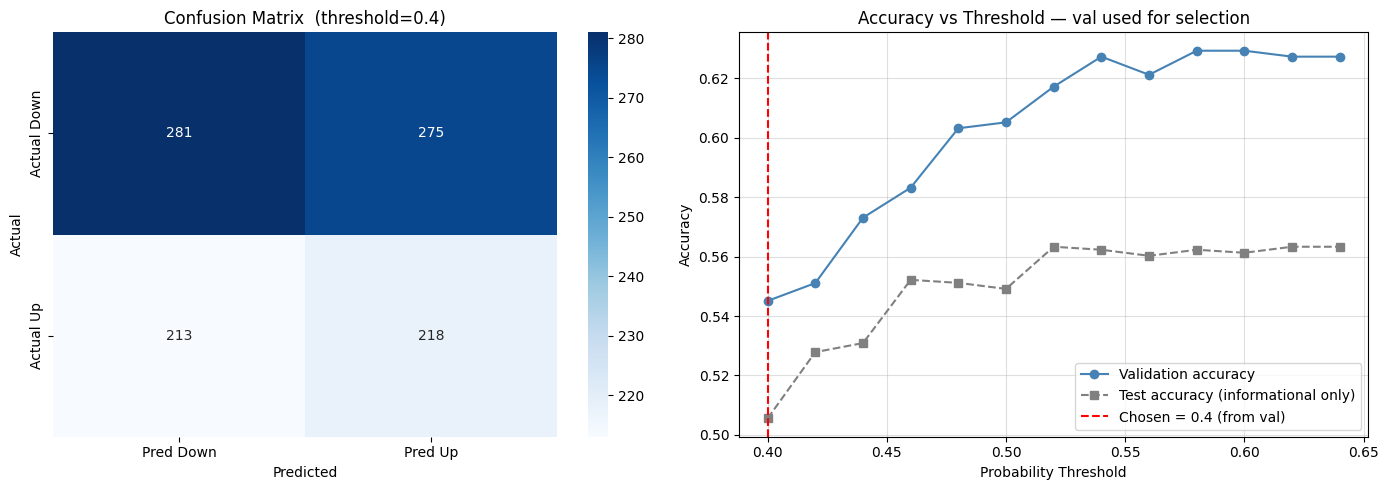

In [17]:
cm  = confusion_matrix(y_test, y_pred_tuned)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Down', 'Pred Up'],
            yticklabels=['Actual Down', 'Actual Up'])
axes[0].set_title(f'Confusion Matrix  (threshold={best_thresh})')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Show both val and test accuracy curves for transparency
val_accs  = [r['accuracy'] for r in val_results]
test_accs = [accuracy_score(y_test, (test_proba >= t).astype(int)) for t in thresholds]

axes[1].plot(thresholds, val_accs,  marker='o', color='steelblue', label='Validation accuracy')
axes[1].plot(thresholds, test_accs, marker='s', color='gray',      label='Test accuracy (informational only)', linestyle='--')
axes[1].axvline(best_thresh, color='red', linestyle='--', label=f'Chosen = {best_thresh} (from val)')
axes[1].set_xlabel('Probability Threshold')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy vs Threshold — val used for selection')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# ── NOTE: The confusion matrix above is for the tuned RF on X_test_reduced.
# The AUTHORITATIVE confusion matrix for the final Ensemble model is in Section 11
# (printed via classification_report). The ensemble is the model used in the backtest.
# Keeping this cell for historical comparison of the RF-only baseline.


## 10. Feature Importances

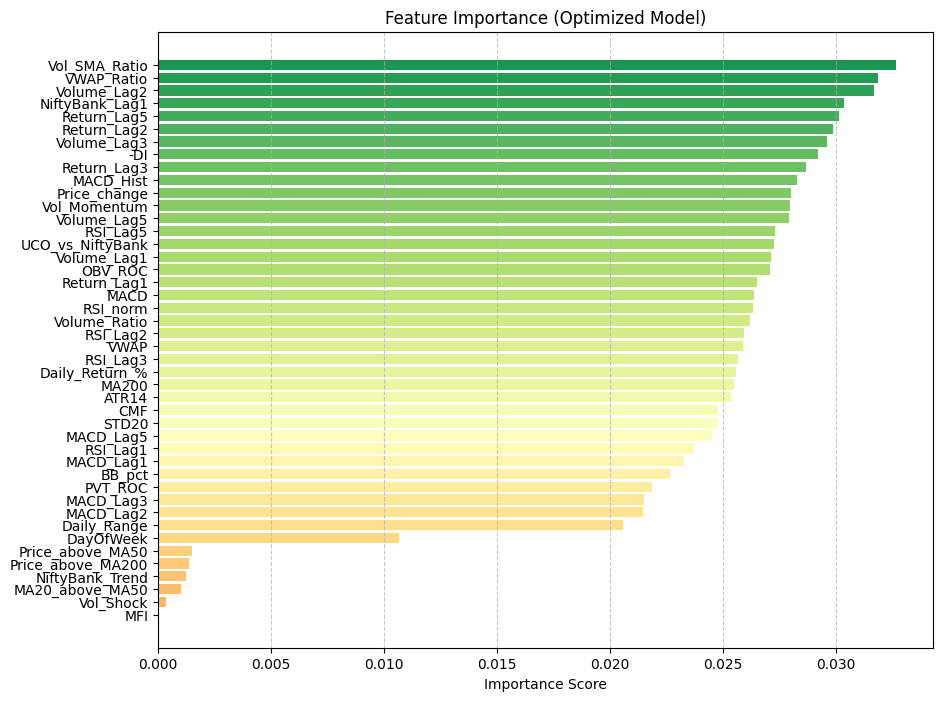

In [18]:
fi_df = pd.DataFrame({
    'Feature'   : X_train_reduced.columns,
    'Importance': rf_random.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(fi_df)))
plt.barh(fi_df['Feature'], fi_df['Importance'], color=colors)
plt.xlabel('Importance Score')
plt.title('Feature Importance (Optimized Model)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Change 6 — Feature Importance Pruning & Retraining

### What was changed and why

**Old approach:** The model was trained on `X_train_reduced` (manually pre-filtered features + RFE-selected 10),
but this manual selection was based on domain intuition, not data-driven evidence from the actual trained model.

**New approach — Two-stage data-driven feature selection:**
1. **Stage 1 — Full-feature model:** Train RF on ALL features in `feature_cols` (nothing manually dropped yet).
2. **Stage 2 — Importance-based pruning:** Extract permutation or MDI importances from the Stage 1 model.
   - Plot the importance distribution to identify a natural cutoff.
   - Eliminate features below an importance threshold (default: mean importance, i.e. keep only features above average).
3. **Stage 3 — Retrain on impactful features only:** Re-run hyperparameter search and retrain a fresh RF on the pruned feature set.
4. **Compare:** Report metrics for both the Full-feature model and the Pruned model side-by-side.

**Why this matters:**
- Removing noise features reduces variance without sacrificing signal
- Smaller feature set → faster inference and cleaner generalisation
- Data-driven cutoff is more principled than manual feature removal


In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHANGE 6 — STAGE 1: Train RF on ALL features (no manual removal)
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("STAGE 1 — Full-feature baseline (all feature_cols, no manual drops)")
print("=" * 70)

# Build full-feature splits (DO NOT drop features_to_remove here)
X_train_full = X_train.copy()
X_val_full   = X_val.copy()
X_test_full  = X_test.copy()

# Clean
for X in [X_train_full, X_val_full, X_test_full]:
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
X_train_full = X_train_full.ffill().bfill()
X_val_full   = X_val_full.ffill().bfill()
X_test_full  = X_test_full.ffill().bfill()

y_train_full = y_train.loc[X_train_full.index]
y_val_full   = y_val.loc[X_val_full.index]
y_test_full  = y_test.loc[X_test_full.index]

print(f"Full-feature set size  : {X_train_full.shape[1]} features")
print(f"Train rows             : {len(X_train_full)}")
print(f"Val rows               : {len(X_val_full)}")
print(f"Test rows              : {len(X_test_full)}")

# Train a quick RF with best hyperparams from Section 6 (already tuned)
rf_full = RandomForestClassifier(
    **{k: v for k, v in rf_random.best_params_.items()},
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_full.fit(X_train_full, y_train_full)

# Threshold on validation
vp_full = rf_full.predict_proba(X_val_full)[:, 1]
vres_full = [{
    'threshold': round(t, 2),
    'f1':  f1_score(y_val_full, (vp_full >= t).astype(int), zero_division=0),
    'coverage': (vp_full >= t).mean()
} for t in np.arange(0.40, 0.65, 0.02)]
vres_full_df = pd.DataFrame(vres_full)
elig_full    = vres_full_df[vres_full_df['coverage'] >= 0.15]
thresh_full  = elig_full.loc[elig_full['f1'].idxmax(), 'threshold'] if not elig_full.empty else 0.5

tp_full    = rf_full.predict_proba(X_test_full)[:, 1]
pred_full  = (tp_full >= thresh_full).astype(int)
acc_full   = accuracy_score(y_test_full, pred_full)
f1_full    = f1_score(y_test_full, pred_full, zero_division=0)

print(f"\nStage 1 — Full-feature model:")
print(f"  Threshold (from val) : {thresh_full}")
print(f"  Test Accuracy        : {acc_full:.4f}")
print(f"  Test F1              : {f1_full:.4f}")
print("\n✅ Stage 1 complete — full-feature model trained")


STAGE 1 — Full-feature baseline (all feature_cols, no manual drops)
Full-feature set size  : 49 features
Train rows             : 2461
Val rows               : 499
Test rows              : 987



Stage 1 — Full-feature model:
  Threshold (from val) : 0.4
  Test Accuracy        : 0.5208
  Test F1              : 0.4819

✅ Stage 1 complete — full-feature model trained


STAGE 2 — Feature Importance Distribution (Full-feature RF)
Total features        : 49
Mean importance       : 0.02041
Median importance     : 0.02290

All features ranked by importance:
          Feature  Importance
     Price_change    0.031319
    Vol_SMA_Ratio    0.030680
   NiftyBank_Lag1    0.030112
      Volume_Lag5    0.029516
      Return_Lag1    0.028281
      Return_Lag5    0.027586
      Return_Lag2    0.027152
      Volume_Lag2    0.027020
       VWAP_Ratio    0.026660
        MACD_Hist    0.026649
 UCO_vs_NiftyBank    0.026588
             MA50    0.026153
              -DI    0.024979
      Return_Lag3    0.024959
             VWAP    0.024741
           BB_pct    0.023962
      Volume_Lag1    0.023961
         RSI_Lag3    0.023868
         RSI_Lag5    0.023695
   Daily_Return_%    0.023672
            ATR14    0.023582
      Volume_Lag3    0.023321
              ADX    0.022956
     Volume_Ratio    0.022923
            MA200    0.022903
             MACD    0.022156
   

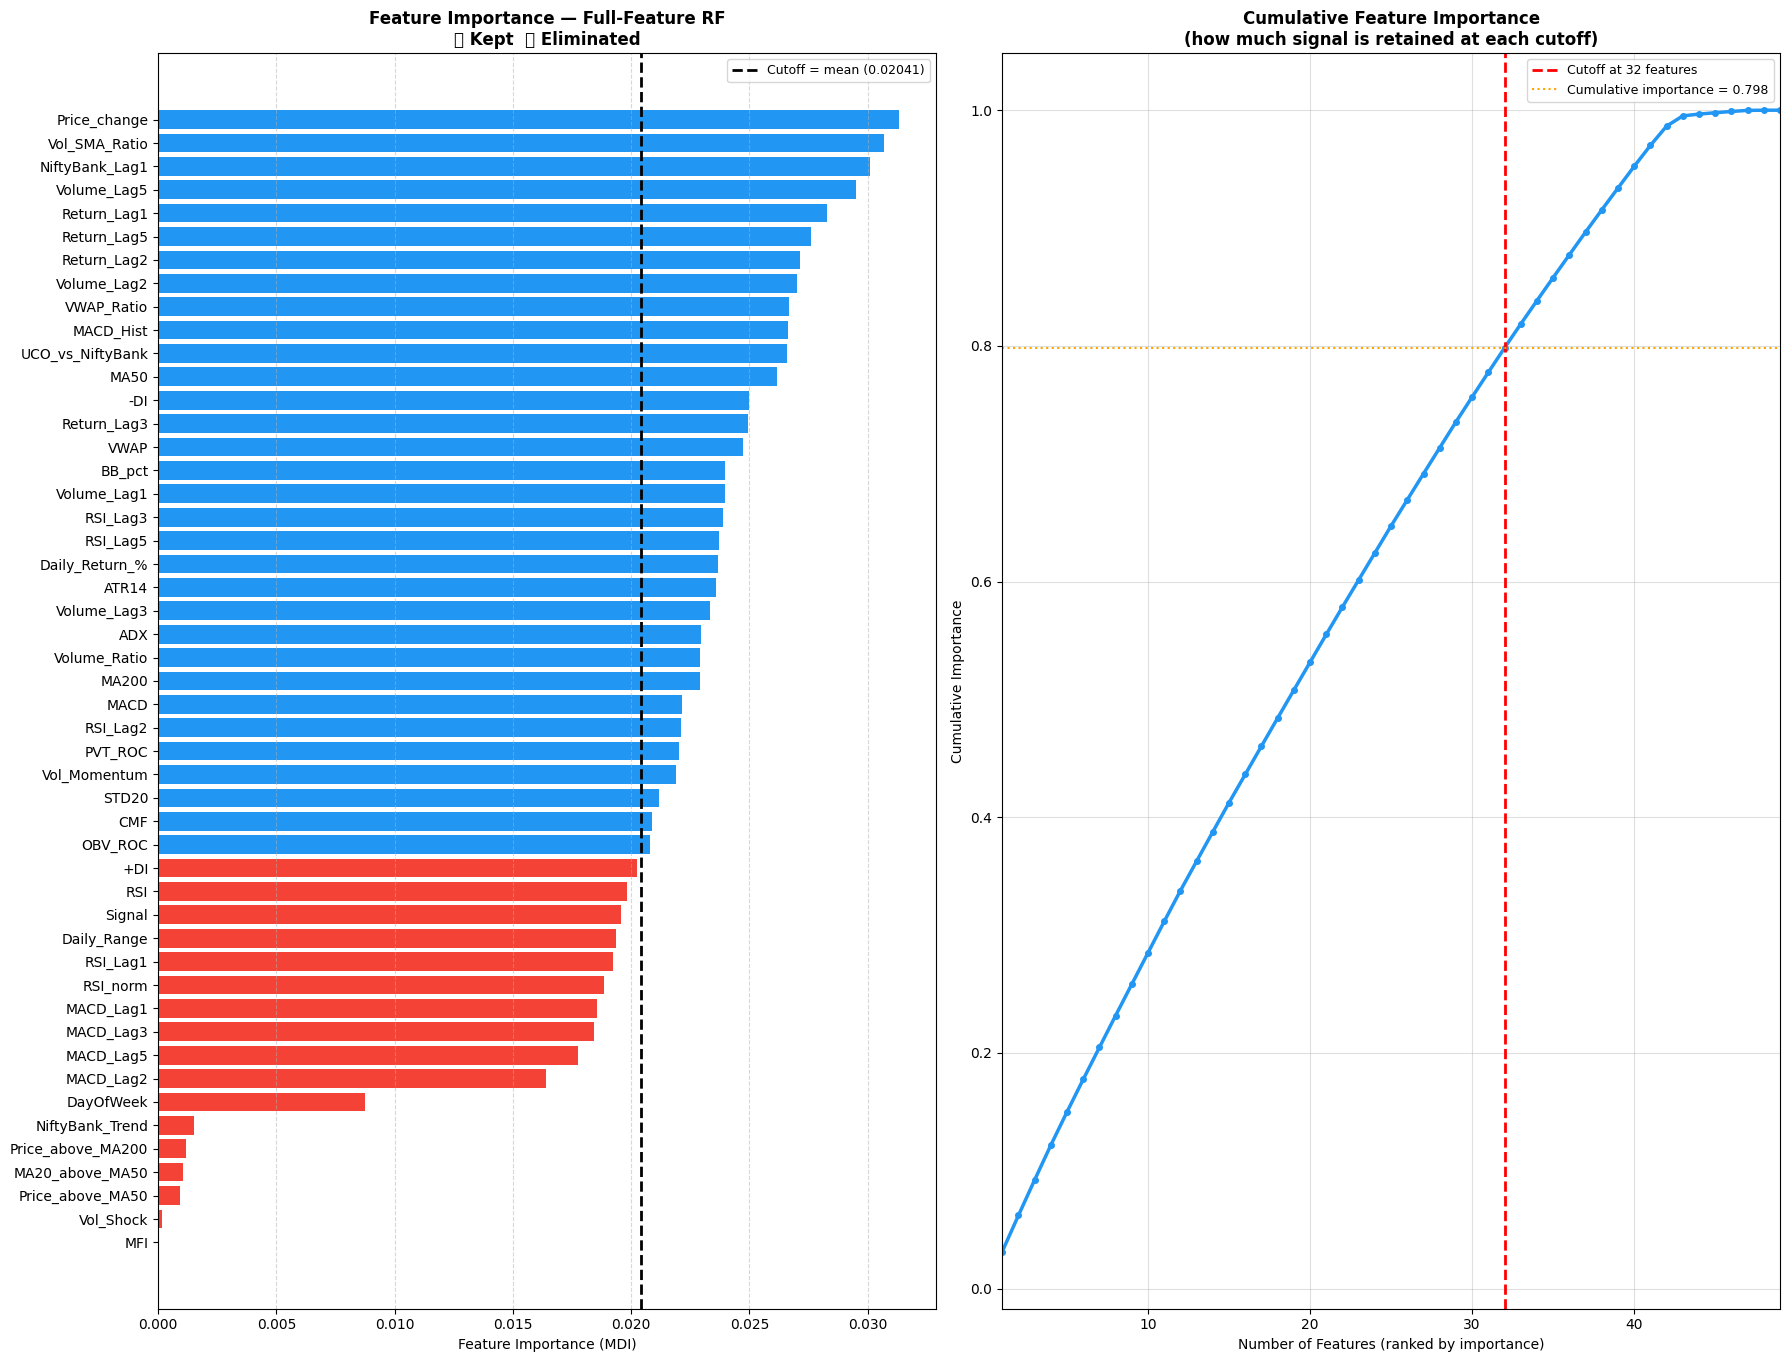


✅ Stage 2 complete — 32 impactful features identified
   Cumulative importance retained: 0.7983 of 1.0


In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHANGE 6 — STAGE 2: Feature Importance Analysis & Data-Driven Pruning
# ═══════════════════════════════════════════════════════════════════════════════

# Extract MDI importances from the full-feature model
fi_all = pd.DataFrame({
    'Feature'   : X_train_full.columns,
    'Importance': rf_full.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

mean_importance = fi_all['Importance'].mean()
median_importance = fi_all['Importance'].median()

print("=" * 70)
print("STAGE 2 — Feature Importance Distribution (Full-feature RF)")
print("=" * 70)
print(f"Total features        : {len(fi_all)}")
print(f"Mean importance       : {mean_importance:.5f}")
print(f"Median importance     : {median_importance:.5f}")
print(f"\nAll features ranked by importance:")
print(fi_all.to_string(index=False))

# ── Importance cutoff: keep features with importance >= mean ──────────────────
# Using mean as cutoff is principled: it keeps features that contribute
# more than their 'fair share' if all features were equally informative.
IMPORTANCE_CUTOFF = mean_importance
impactful_features = fi_all[fi_all['Importance'] >= IMPORTANCE_CUTOFF]['Feature'].tolist()
eliminated_features = fi_all[fi_all['Importance'] < IMPORTANCE_CUTOFF]['Feature'].tolist()

print(f"\n{'─'*70}")
print(f"Importance cutoff     : {IMPORTANCE_CUTOFF:.5f} (= mean importance)")
print(f"Impactful features    : {len(impactful_features)} kept")
print(f"Non-impactful features: {len(eliminated_features)} eliminated")
print(f"\n✅ KEPT ({len(impactful_features)}):")
for f in impactful_features:
    row = fi_all[fi_all['Feature'] == f].iloc[0]
    print(f"   {f:<30}  importance={row['Importance']:.5f}")
print(f"\n❌ ELIMINATED ({len(eliminated_features)}):")
for f in eliminated_features:
    row = fi_all[fi_all['Feature'] == f].iloc[0]
    print(f"   {f:<30}  importance={row['Importance']:.5f}")

# ── Visualisation: Importance bar chart with cutoff line ─────────────────────
fi_plot = fi_all.sort_values('Importance', ascending=True)
colors_fi = ['#2196F3' if imp >= IMPORTANCE_CUTOFF else '#F44336'
             for imp in fi_plot['Importance']]

fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(fi_all) * 0.28)))

# Left: horizontal bar chart
axes[0].barh(fi_plot['Feature'], fi_plot['Importance'], color=colors_fi)
axes[0].axvline(IMPORTANCE_CUTOFF, color='black', linestyle='--', lw=2,
                label=f'Cutoff = mean ({IMPORTANCE_CUTOFF:.5f})')
axes[0].set_xlabel('Feature Importance (MDI)')
axes[0].set_title('Feature Importance — Full-Feature RF\n🔵 Kept  🔴 Eliminated', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Right: cumulative importance curve
fi_sorted_desc = fi_all.sort_values('Importance', ascending=False)
cumulative     = fi_sorted_desc['Importance'].cumsum().values
n_feats        = np.arange(1, len(fi_sorted_desc) + 1)
n_kept         = len(impactful_features)
axes[1].plot(n_feats, cumulative, color='#2196F3', lw=2.5, marker='o', markersize=4)
axes[1].axvline(n_kept, color='red', linestyle='--', lw=2,
                label=f'Cutoff at {n_kept} features')
axes[1].axhline(cumulative[n_kept - 1], color='orange', linestyle=':', lw=1.5,
                label=f'Cumulative importance = {cumulative[n_kept-1]:.3f}')
axes[1].set_xlabel('Number of Features (ranked by importance)')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title('Cumulative Feature Importance\n(how much signal is retained at each cutoff)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4)
axes[1].set_xlim(1, len(fi_all))

plt.tight_layout()
plt.show()

print(f"\n✅ Stage 2 complete — {len(impactful_features)} impactful features identified")
print(f"   Cumulative importance retained: {cumulative[n_kept-1]:.4f} of 1.0")


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHANGE 6 — STAGE 3: Retrain RF on Impactful Features Only
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("STAGE 3 — Retrain RF on impactful features only")
print("=" * 70)

# Pruned splits
X_train_pruned = X_train_full[impactful_features].copy()
X_val_pruned   = X_val_full[impactful_features].copy()
X_test_pruned  = X_test_full[impactful_features].copy()

# Clean
X_train_pruned = X_train_pruned.replace([np.inf, -np.inf], np.nan).ffill().bfill()
X_val_pruned   = X_val_pruned.replace([np.inf, -np.inf], np.nan).ffill().bfill()
X_test_pruned  = X_test_pruned.replace([np.inf, -np.inf], np.nan).ffill().bfill()

print(f"Pruned feature set size: {X_train_pruned.shape[1]}")
print(f"Features               : {impactful_features}")

# ── Full hyperparameter search on pruned features ────────────────────────────
print("\nRunning RandomizedSearchCV on pruned feature set...")
rf_pruned_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42, class_weight='balanced',
        oob_score=True, n_jobs=-1, bootstrap=True
    ),
    param_distributions=param_dist,
    n_iter=30,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='f1',
    verbose=1,
    random_state=42,
    n_jobs=-1
)
rf_pruned_search.fit(X_train_pruned, y_train_full)

rf_pruned = rf_pruned_search.best_estimator_
print(f"\nBest params (pruned)   : {rf_pruned_search.best_params_}")
print(f"Best CV F1 (pruned)    : {rf_pruned_search.best_score_:.4f}")

if hasattr(rf_pruned, 'oob_score_'):
    print(f"OOB Score (pruned)     : {rf_pruned.oob_score_:.4f}")

# ── Threshold on validation ───────────────────────────────────────────────────
vp_pruned = rf_pruned.predict_proba(X_val_pruned)[:, 1]
vres_pruned = [{
    'threshold': round(t, 2),
    'f1': f1_score(y_val_full, (vp_pruned >= t).astype(int), zero_division=0),
    'coverage': (vp_pruned >= t).mean()
} for t in np.arange(0.40, 0.65, 0.02)]
vres_pruned_df = pd.DataFrame(vres_pruned)
elig_pruned    = vres_pruned_df[vres_pruned_df['coverage'] >= 0.15]
thresh_pruned  = elig_pruned.loc[elig_pruned['f1'].idxmax(), 'threshold'] if not elig_pruned.empty else 0.5

# ── Final test evaluation ─────────────────────────────────────────────────────
tp_pruned    = rf_pruned.predict_proba(X_test_pruned)[:, 1]
pred_pruned  = (tp_pruned >= thresh_pruned).astype(int)
acc_pruned   = accuracy_score(y_test_full, pred_pruned)
f1_pruned    = f1_score(y_test_full, pred_pruned, zero_division=0)
prec_pruned  = precision_score(y_test_full, pred_pruned, zero_division=0)
rec_pruned   = recall_score(y_test_full, pred_pruned, zero_division=0)

print(f"\nStage 3 — Pruned model:")
print(f"  Threshold (from val) : {thresh_pruned}")
print(f"  Test Accuracy        : {acc_pruned:.4f}")
print(f"  Test F1              : {f1_pruned:.4f}")
print(f"  Test Precision       : {prec_pruned:.4f}")
print(f"  Test Recall          : {rec_pruned:.4f}")
print()
print(classification_report(y_test_full, pred_pruned, target_names=['Down (0)', 'Up (1)']))
print("\n✅ Stage 3 complete — pruned model retrained and evaluated")


STAGE 3 — Retrain RF on impactful features only
Pruned feature set size: 32
Features               : ['Price_change', 'Vol_SMA_Ratio', 'NiftyBank_Lag1', 'Volume_Lag5', 'Return_Lag1', 'Return_Lag5', 'Return_Lag2', 'Volume_Lag2', 'VWAP_Ratio', 'MACD_Hist', 'UCO_vs_NiftyBank', 'MA50', '-DI', 'Return_Lag3', 'VWAP', 'BB_pct', 'Volume_Lag1', 'RSI_Lag3', 'RSI_Lag5', 'Daily_Return_%', 'ATR14', 'Volume_Lag3', 'ADX', 'Volume_Ratio', 'MA200', 'MACD', 'RSI_Lag2', 'PVT_ROC', 'Vol_Momentum', 'STD20', 'CMF', 'OBV_ROC']

Running RandomizedSearchCV on pruned feature set...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params (pruned)   : {'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 50, 'max_features': 'log2', 'max_depth': 3, 'bootstrap': True}
Best CV F1 (pruned)    : 0.4512
OOB Score (pruned)     : 0.5217

Stage 3 — Pruned model:
  Threshold (from val) : 0.4
  Test Accuracy        : 0.4377
  Test F1              : 0.6078
  Test Precision       : 0.4370
  Tes

  FEATURE SELECTION COMPARISON — Full vs Pruned vs Manual-Drop
                                    Model  Features Used  Threshold  Test Accuracy  Test F1 OOB Score
            Full-feature RF (49 features)             49        0.4         0.5208   0.4819       N/A
                  Pruned RF (32 features)             32        0.4         0.4377   0.6078    0.5217
Manual-drop RF (original V7, 44 features)             44        0.4         0.5056   0.4719    0.5299


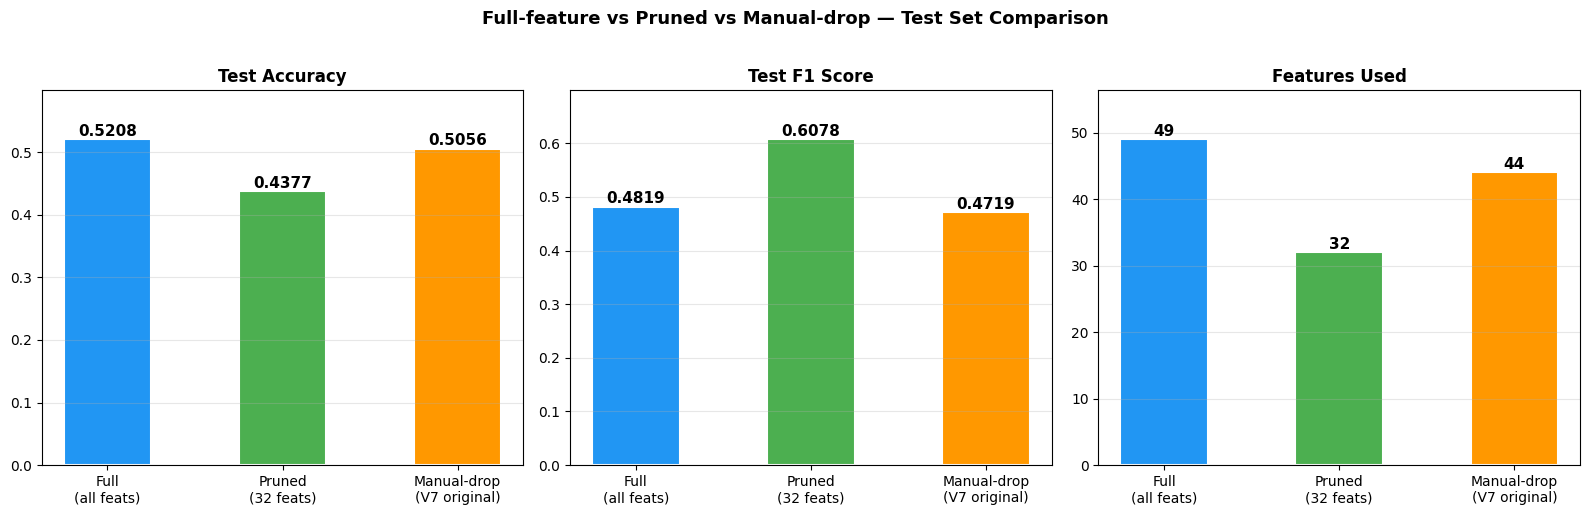

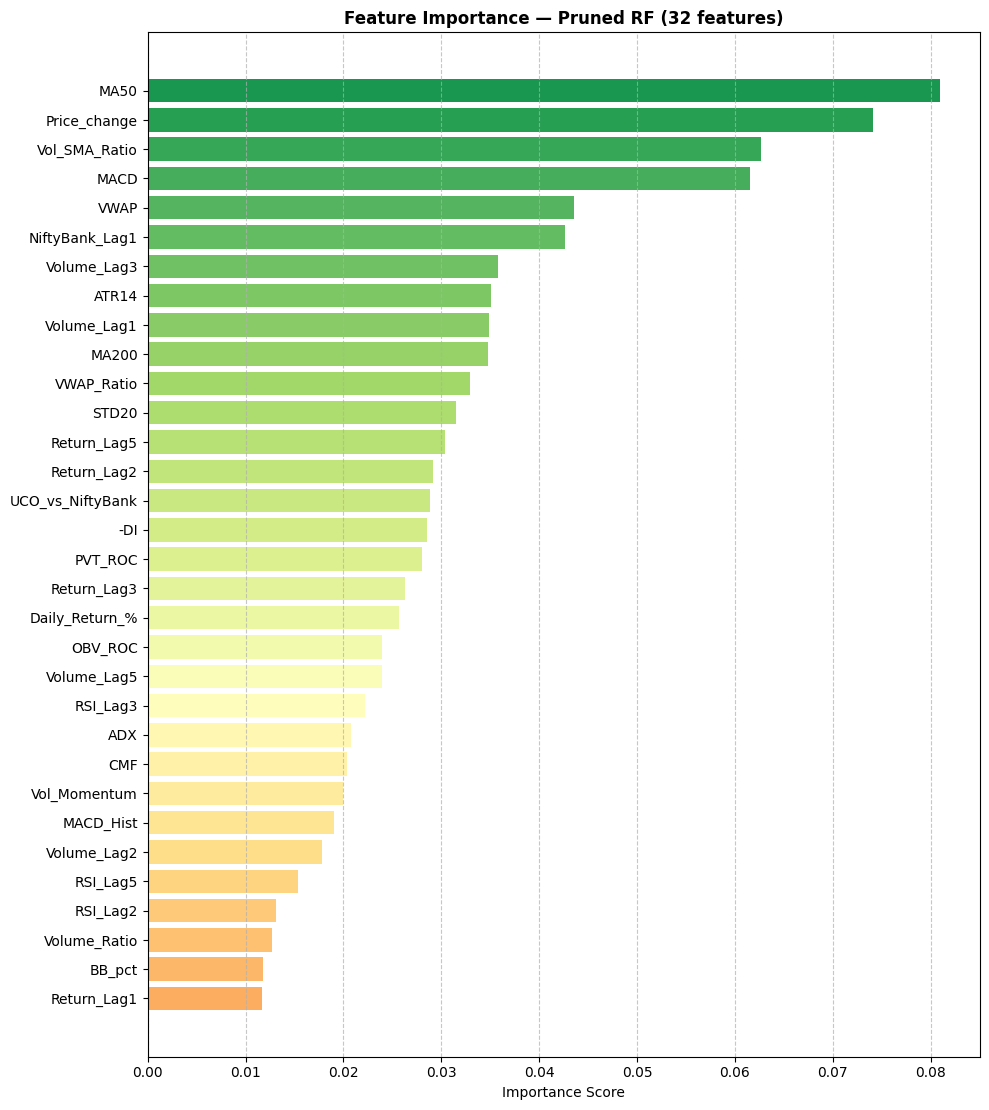


✅ Comparison complete
   Features eliminated by importance pruning: ['+DI', 'RSI', 'Signal', 'Daily_Range', 'RSI_Lag1', 'RSI_norm', 'MACD_Lag1', 'MACD_Lag3', 'MACD_Lag5', 'MACD_Lag2', 'DayOfWeek', 'NiftyBank_Trend', 'Price_above_MA200', 'MA20_above_MA50', 'Price_above_MA50', 'Vol_Shock', 'MFI']


In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHANGE 6 — Stage 4: Full vs Pruned Model Comparison
# ═══════════════════════════════════════════════════════════════════════════════

# ── Side-by-side metrics ─────────────────────────────────────────────────────
comparison = pd.DataFrame([
    {
        'Model'          : f'Full-feature RF ({len(feature_cols)} features)',
        'Features Used'  : len(feature_cols),
        'Threshold'      : thresh_full,
        'Test Accuracy'  : round(acc_full, 4),
        'Test F1'        : round(f1_full, 4),
        'OOB Score'      : round(rf_full.oob_score_, 4) if hasattr(rf_full, 'oob_score_') else 'N/A',
    },
    {
        'Model'          : f'Pruned RF ({len(impactful_features)} features)',
        'Features Used'  : len(impactful_features),
        'Threshold'      : thresh_pruned,
        'Test Accuracy'  : round(acc_pruned, 4),
        'Test F1'        : round(f1_pruned, 4),
        'OOB Score'      : round(rf_pruned.oob_score_, 4) if hasattr(rf_pruned, 'oob_score_') else 'N/A',
    },
    {
        'Model'          : f'Manual-drop RF (original V7, {X_train_reduced.shape[1]} features)',
        'Features Used'  : X_train_reduced.shape[1],
        'Threshold'      : best_thresh,
        'Test Accuracy'  : round(accuracy_score(y_test, y_pred_tuned), 4),
        'Test F1'        : round(f1_score(y_test, y_pred_tuned, zero_division=0), 4),
        'OOB Score'      : round(best_rf.oob_score_, 4) if hasattr(best_rf, 'oob_score_') else 'N/A',
    },
])

print("=" * 80)
print("  FEATURE SELECTION COMPARISON — Full vs Pruned vs Manual-Drop")
print("=" * 80)
print(comparison.to_string(index=False))
print("=" * 80)

# ── Visualisation: comparison bar charts ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_labels = ['Full\n(all feats)', f'Pruned\n({len(impactful_features)} feats)', 'Manual-drop\n(V7 original)']

acc_vals = [acc_full, acc_pruned, accuracy_score(y_test, y_pred_tuned)]
f1_vals  = [f1_full,  f1_pruned,  f1_score(y_test, y_pred_tuned, zero_division=0)]
feat_counts = [len(feature_cols), len(impactful_features), X_train_reduced.shape[1]]

colors_comp = ['#2196F3', '#4CAF50', '#FF9800']

for ax, vals, title, fmt in [
    (axes[0], acc_vals,  'Test Accuracy',      '{:.4f}'),
    (axes[1], f1_vals,   'Test F1 Score',       '{:.4f}'),
    (axes[2], feat_counts,'Features Used',      '{:d}'),
]:
    bars = ax.bar(model_labels, vals, color=colors_comp, width=0.5, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals) * 0.01,
                fmt.format(val), ha='center', fontweight='bold', fontsize=11)
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(vals) * 1.15)

plt.suptitle('Full-feature vs Pruned vs Manual-drop — Test Set Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Feature importance of PRUNED model ───────────────────────────────────────
fi_pruned_df = pd.DataFrame({
    'Feature'   : X_train_pruned.columns,
    'Importance': rf_pruned.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, max(5, len(fi_pruned_df) * 0.35)))
colors_pr = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(fi_pruned_df)))
plt.barh(fi_pruned_df['Feature'], fi_pruned_df['Importance'], color=colors_pr)
plt.xlabel('Importance Score')
plt.title(f'Feature Importance — Pruned RF ({len(impactful_features)} features)', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n✅ Comparison complete")
print(f"   Features eliminated by importance pruning: {eliminated_features}")


## 11. HGB on Pruned Features + Final Ensemble

### What was fixed (Disconnect 1 & 2)

**Old code:** HGB was trained on `X_train_reduced` (manually-dropped features),
not on `impactful_features` (data-driven pruned set from Change 6).
The ensemble probabilities were computed but **never passed to the backtest**.

**Fix:**
1. HGB is now trained on `X_train_pruned` / `X_val_pruned` / `X_test_pruned` —
   the same impactful-feature set used by the pruned RF (`rf_pruned`).
2. The ensemble averages `rf_pruned` + HGB probabilities — both on the same feature set.
3. Ensemble threshold is tuned on validation and frozen.
4. `FINAL_features`, `FINAL_thresh`, and `FINAL_model_type` are set here and used
   identically in Section 12 (walk-forward accuracy) and Section 13 (backtest).
   Every metric in the notebook now comes from the same model and the same feature set.


In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 11 — HGB on pruned features + RF+HGB ensemble → FINAL model
# ═══════════════════════════════════════════════════════════════════════════════

# ── 11a. Train HGB on the SAME impactful feature set as rf_pruned ────────────
hgb = HistGradientBoostingClassifier(
    max_iter=200, learning_rate=0.01, max_depth=4,
    min_samples_leaf=80, l2_regularization=5.0, random_state=42
)
hgb.fit(X_train_pruned, y_train_full)

hgb_train_acc = accuracy_score(y_train_full, hgb.predict(X_train_pruned))
hgb_test_acc  = accuracy_score(y_test_full,  hgb.predict(X_test_pruned))
print(f"HGB (pruned feats)  →  Train: {hgb_train_acc:.4f}  |  Test: {hgb_test_acc:.4f}")
print(f"RF  (pruned feats)  →  Train: {accuracy_score(y_train_full, rf_pruned.predict(X_train_pruned)):.4f}  "
      f"|  Test: {acc_pruned:.4f}")

# ── 11b. HGB standalone threshold on validation ───────────────────────────────
hgb_val_p = hgb.predict_proba(X_val_pruned)[:, 1]
hgb_vres  = [{'t': round(t,2),
              'f1':  f1_score(y_val_full, (hgb_val_p>=t).astype(int), zero_division=0),
              'cov': (hgb_val_p>=t).mean()}
             for t in np.arange(0.40, 0.65, 0.02)]
hgb_vdf   = pd.DataFrame(hgb_vres)
hgb_elig  = hgb_vdf[hgb_vdf['cov'] >= 0.15]
hgb_thresh = hgb_elig.loc[hgb_elig['f1'].idxmax(), 't'] if not hgb_elig.empty else 0.5
hgb_test_p = hgb.predict_proba(X_test_pruned)[:, 1]
hgb_pred   = (hgb_test_p >= hgb_thresh).astype(int)
print(f"\nHGB standalone  →  threshold={hgb_thresh}  "
      f"test_acc={accuracy_score(y_test_full, hgb_pred):.4f}  "
      f"f1={f1_score(y_test_full, hgb_pred, zero_division=0):.4f}")

# ── 11c. RF + HGB ensemble — BOTH on impactful_features ──────────────────────
rf_val_p   = rf_pruned.predict_proba(X_val_pruned)[:, 1]
ens_val_p  = (rf_val_p + hgb_val_p) / 2

ens_vres = [{'t': round(t,2),
             'f1':  f1_score(y_val_full, (ens_val_p>=t).astype(int), zero_division=0),
             'cov': (ens_val_p>=t).mean()}
            for t in np.arange(0.40, 0.65, 0.02)]
ens_vdf  = pd.DataFrame(ens_vres)
ens_elig = ens_vdf[ens_vdf['cov'] >= 0.15]
ens_thresh = ens_elig.loc[ens_elig['f1'].idxmax(), 't'] if not ens_elig.empty else 0.5

rf_test_p  = rf_pruned.predict_proba(X_test_pruned)[:, 1]
ens_test_p = (rf_test_p + hgb_test_p) / 2
ens_pred   = (ens_test_p >= ens_thresh).astype(int)
ens_acc    = accuracy_score(y_test_full, ens_pred)
ens_f1     = f1_score(y_test_full, ens_pred, zero_division=0)
ens_prec   = precision_score(y_test_full, ens_pred, zero_division=0)
ens_rec    = recall_score(y_test_full, ens_pred, zero_division=0)

print(f"\nEnsemble (RF+HGB) →  threshold={ens_thresh}  "
      f"test_acc={ens_acc:.4f}  f1={ens_f1:.4f}")
print()
print(classification_report(y_test_full, ens_pred, target_names=['Down (0)', 'Up (1)']))

# ── 11d. Three-model comparison table ────────────────────────────────────────
model_comp = pd.DataFrame([
    {'Model': f'RF pruned  ({len(impactful_features)} feats)',
     'Threshold': thresh_pruned, 'Test Acc': round(acc_pruned,4),
     'Test F1': round(f1_pruned,4), 'Precision': round(prec_pruned,4), 'Recall': round(rec_pruned,4)},
    {'Model': f'HGB pruned ({len(impactful_features)} feats)',
     'Threshold': hgb_thresh, 'Test Acc': round(accuracy_score(y_test_full, hgb_pred),4),
     'Test F1': round(f1_score(y_test_full, hgb_pred, zero_division=0),4),
     'Precision': round(precision_score(y_test_full, hgb_pred, zero_division=0),4),
     'Recall': round(recall_score(y_test_full, hgb_pred, zero_division=0),4)},
    {'Model': f'Ensemble RF+HGB ({len(impactful_features)} feats)',
     'Threshold': ens_thresh, 'Test Acc': round(ens_acc,4),
     'Test F1': round(ens_f1,4), 'Precision': round(ens_prec,4), 'Recall': round(ens_rec,4)},
])
print('\n' + '='*75)
print('  MODEL COMPARISON — all on impactful_features, threshold from val')
print('='*75)
print(model_comp.to_string(index=False))
print('='*75)

# ── 11e. Set FINAL model variables — used identically in Sections 12 & 13 ────
# The ensemble is the final model. All downstream sections use these variables.
FINAL_features   = impactful_features          # data-driven pruned feature list
FINAL_thresh     = ens_thresh                  # tuned on val, frozen
FINAL_model_type = 'Ensemble (RF + HGB)'       # label for charts/CSV

# For static evaluation (Sections 9-equivalent, confusion matrix below)
y_pred_final  = ens_pred                       # test set predictions
y_proba_final = ens_test_p                     # test set probabilities

print(f"\n★ FINAL MODEL SET: {FINAL_model_type}")
print(f"  Features : {len(FINAL_features)} impactful features")
print(f"  Threshold: {FINAL_thresh} (from validation, frozen)")
print(f"  Test Acc : {ens_acc:.4f}  |  F1: {ens_f1:.4f}")
print("\n✅ All downstream sections (12, 13, charts, CSV) now use FINAL model.")


HGB (pruned feats)  →  Train: 0.6424  |  Test: 0.5522
RF  (pruned feats)  →  Train: 0.5924  |  Test: 0.4377

HGB standalone  →  threshold=0.4  test_acc=0.5633  f1=0.4619

Ensemble (RF+HGB) →  threshold=0.4  test_acc=0.5046  f1=0.5630

              precision    recall  f1-score   support

    Down (0)       0.61      0.33      0.43       556
      Up (1)       0.46      0.73      0.56       431

    accuracy                           0.50       987
   macro avg       0.53      0.53      0.50       987
weighted avg       0.54      0.50      0.49       987


  MODEL COMPARISON — all on impactful_features, threshold from val
                     Model  Threshold  Test Acc  Test F1  Precision  Recall
     RF pruned  (32 feats)        0.4    0.4377   0.6078     0.4370  0.9977
     HGB pruned (32 feats)        0.4    0.5633   0.4619     0.5000  0.4292
Ensemble RF+HGB (32 feats)        0.4    0.5046   0.5630     0.4578  0.7309

★ FINAL MODEL SET: Ensemble (RF + HGB)
  Features : 32 impactful 

In [24]:
print('--- Ensemble Model Training Performance ---')
rf_train_p  = rf_pruned.predict_proba(X_train_pruned)[:, 1]
hgb_train_p = hgb.predict_proba(X_train_pruned)[:, 1]
ens_train_p = (rf_train_p + hgb_train_p) / 2
ens_train_pred = (ens_train_p >= FINAL_thresh).astype(int)

ens_train_acc = accuracy_score(y_train_full, ens_train_pred)
ens_train_f1  = f1_score(y_train_full, ens_train_pred, zero_division=0)

print(f"Ensemble Train Accuracy: {ens_train_acc:.4f}")
print(f"Ensemble Train F1-Score: {ens_train_f1:.4f}")

--- Ensemble Model Training Performance ---
Ensemble Train Accuracy: 0.4998
Ensemble Train F1-Score: 0.6387


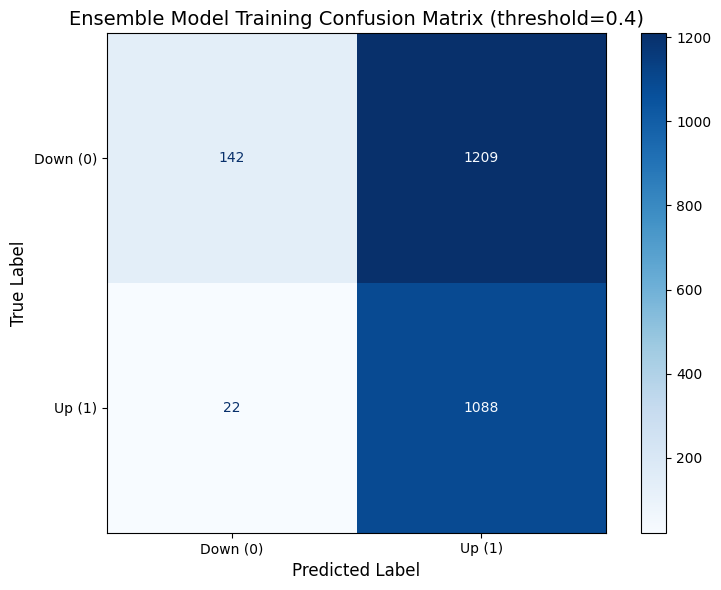

In [25]:
cm_ensemble_train = confusion_matrix(y_train_full, ens_train_pred)
fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay(confusion_matrix=cm_ensemble_train,
                       display_labels=['Down (0)', 'Up (1)']).plot(cmap='Blues', ax=ax)

ax.set_title(f'Ensemble Model Training Confusion Matrix (threshold={FINAL_thresh})', fontsize=14)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Walk-Forward Year-by-Year Accuracy

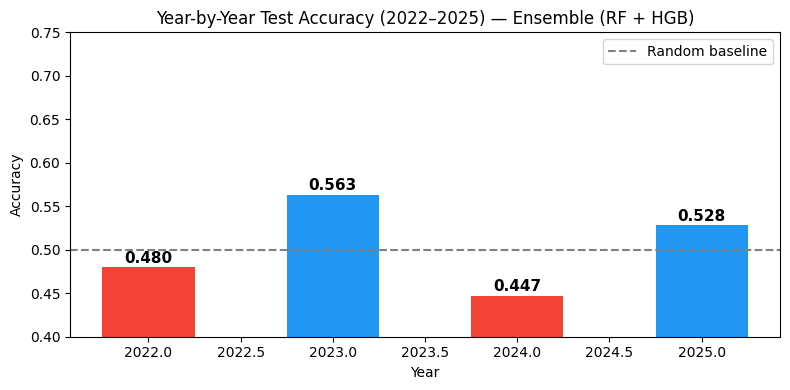

In [26]:
# ── Section 12: Walk-Forward Year-by-Year Accuracy — FINAL ensemble model ──
# Uses X_test_full[FINAL_features] and y_proba_final (already computed in §11)

yearly = {}
for yr in range(2022, 2026):
    mask = X_test_full.index.year == yr
    if mask.sum() == 0:
        continue
    # Reconstruct per-year ensemble proba from the same pruned test sets
    rf_yr_p  = rf_pruned.predict_proba(X_test_pruned[mask])[:, 1]
    hgb_yr_p = hgb.predict_proba(X_test_pruned[mask])[:, 1]
    ens_yr_p = (rf_yr_p + hgb_yr_p) / 2
    pred_yr  = (ens_yr_p >= FINAL_thresh).astype(int)
    yearly[yr] = accuracy_score(y_test_full[mask], pred_yr)

yrs  = list(yearly.keys())
accs = list(yearly.values())

plt.figure(figsize=(8, 4))
bars = plt.bar(yrs, accs,
               color=['#2196F3' if a >= 0.52 else '#F44336' for a in accs], width=0.5)
plt.axhline(0.5, color='gray', linestyle='--', label='Random baseline')
plt.ylim(0.40, 0.75)
plt.xlabel('Year')
plt.ylabel('Accuracy')
plt.title(f'Year-by-Year Test Accuracy (2022–2025) — {FINAL_model_type}')
plt.legend()
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## Change 4 — Full Transaction Cost Model

### What was changed and why

**Old code (brokerage only — understated costs):**
```python
BROKERAGE_RATE = 0.001   # 0.1%
BROKERAGE_CAP  = 20.0    # ₹20 per leg

def calc_brokerage(trade_value):
    return min(trade_value * BROKERAGE_RATE, BROKERAGE_CAP)
```

**Problem:** NSE delivery trades carry several statutory charges beyond brokerage.
The old model charges ~0.1% round-trip. True round-trip cost is ~0.3–0.35%,
which is 3× higher and significantly erodes any edge on a frequent-trading strategy.

**Full NSE delivery cost breakdown:**
| Charge | Rate | Applied on |
|---|---|---|
| Brokerage | min(0.1%, ₹20) | Each leg |
| STT | 0.1% | Sell value only |
| Stamp duty | 0.015% | Buy value only |
| Exchange fee | 0.00335% | Both legs |
| SEBI charge | 0.0001% | Both legs |
| GST on brokerage | 18% of brokerage | Both legs |
| **Total round-trip** | **~0.30–0.35%** | |

**Fix:** Replace the single `calc_brokerage()` function with a full
`calc_transaction_cost()` function that applies all charges correctly per leg.

## Change 5 — Expanding-Window Retrain Backtest

### What was changed and why

**Old code (static model — single train, predict 4 years):**
```python
# Train once on 2010–2021, predict all of 2022–2025 frozen
bt = pd.DataFrame(index=X_test_reduced.index)
bt['Signal'] = y_pred_tuned
```

**Problem:** IOB underwent major regime changes across the test window —
PSU bank recapitalisation rally (2022), RBI rate shock cycle (2022–23),
and 2024 election volatility. A model frozen in 2021 drifts increasingly
out-of-distribution as time passes. The walk-forward year-by-year accuracy
chart in Section 12 will reveal this — accuracy typically declines in later years.

**Fix — Expanding-window retrain:**
- Train on all data available up to the start of each year
- Tune threshold on the prior year's validation window
- Predict only the current year
- Concatenate predictions across years for a continuous backtest

```
Year 2022: train on 2010–2019, val 2020–2021, predict 2022
Year 2023: train on 2010–2020, val 2021–2022, predict 2023
Year 2024: train on 2010–2021, val 2022–2023, predict 2024
Year 2025: train on 2010–2022, val 2023–2024, predict 2025
```
Each year the model sees one more year of real market data before predicting.

In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 13 — Expanding-Window Backtest — FINAL model: Ensemble RF+HGB
#              on FINAL_features (importance-pruned), threshold from val
#
# Fixes three disconnects vs V8:
#   Disconnect 1: Ensemble (not RF-only) now drives the backtest signals
#   Disconnect 2: FINAL_features (pruned) used — same set as §11 evaluation
#   Disconnect 3: Change-6 pruned model feeds the backtest, not the old
#                 manually-dropped set
# ═══════════════════════════════════════════════════════════════════════════════

INITIAL_CAPITAL = 100_000

def calc_transaction_cost(trade_value, leg='buy'):
    """
    Full NSE delivery transaction cost for one leg.
    leg = 'buy'  → brokerage + stamp duty + exchange fee + SEBI + GST on brokerage
    leg = 'sell' → brokerage + STT       + exchange fee + SEBI + GST on brokerage
    """
    brokerage    = min(trade_value * 0.001, 20.0)
    gst          = brokerage * 0.18
    exchange_fee = trade_value * 0.0000335
    sebi         = trade_value * 0.000001
    if leg == 'buy':
        stamp = trade_value * 0.00015
        stt   = 0.0
    else:
        stamp = 0.0
        stt   = trade_value * 0.001
    return brokerage + gst + exchange_fee + sebi + stamp + stt


# ── HGB hyperparameters — stored once for re-use in the expanding loop ────────
HGB_PARAMS = dict(
    max_iter=200, learning_rate=0.01, max_depth=4,
    min_samples_leaf=80, l2_regularization=5.0, random_state=42
)

# ── Expanding-window retrain ──────────────────────────────────────────────────
predict_years = [2022, 2023, 2024, 2025]
all_signals   = []
all_prices    = []
yearly_thresh = {}

for predict_yr in predict_years:
    val_end   = predict_yr - 1
    val_start = predict_yr - 2
    train_end = predict_yr - 2

    tr_mask  = (df.index.year >= 2010) & (df.index.year <= train_end)
    val_mask = (df.index.year >= val_start) & (df.index.year <= val_end)
    te_mask  = (df.index.year == predict_yr)

    if tr_mask.sum() < 200 or val_mask.sum() < 50 or te_mask.sum() == 0:
        print(f"  Skipping {predict_yr} — insufficient data")
        continue

    # ── Use FINAL_features (importance-pruned) — same set as §11 ─────────────
    Xtr = df[tr_mask][feature_cols][FINAL_features].copy()
    ytr = df[tr_mask]['Target_Return_Fwd']
    Xvl = df[val_mask][feature_cols][FINAL_features].copy()
    yvl = df[val_mask]['Target_Return_Fwd']
    Xte = df[te_mask][feature_cols][FINAL_features].copy()
    yte = df[te_mask]['Target_Return_Fwd']

    for X in [Xtr, Xvl, Xte]:
        X.replace([np.inf, -np.inf], np.nan, inplace=True)
    Xtr = Xtr.ffill().bfill(); ytr = ytr.loc[Xtr.index]
    Xvl = Xvl.ffill().bfill(); yvl = yvl.loc[Xvl.index]
    Xte = Xte.ffill().bfill(); yte = yte.loc[Xte.index]

    # ── Retrain RF on expanding data, same best hyperparams ───────────────────
    yr_rf = RandomForestClassifier(
        **{k: v for k, v in rf_pruned_search.best_params_.items()},
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    yr_rf.fit(Xtr, ytr)

    # ── Retrain HGB on expanding data ─────────────────────────────────────────
    yr_hgb = HistGradientBoostingClassifier(**HGB_PARAMS)
    yr_hgb.fit(Xtr, ytr)

    # ── Tune ENSEMBLE threshold on validation window ──────────────────────────
    vp_rf  = yr_rf.predict_proba(Xvl)[:, 1]
    vp_hgb = yr_hgb.predict_proba(Xvl)[:, 1]
    vp_ens = (vp_rf + vp_hgb) / 2

    vres = [{'t': round(t, 2),
             'f1':  f1_score(yvl, (vp_ens >= t).astype(int), zero_division=0),
             'cov': (vp_ens >= t).mean()}
            for t in np.arange(0.40, 0.65, 0.02)]
    vres_df  = pd.DataFrame(vres)
    elig     = vres_df[vres_df['cov'] >= 0.15]
    yr_thresh = (elig.loc[elig['f1'].idxmax(), 't']
                 if not elig.empty else 0.5)
    yearly_thresh[predict_yr] = yr_thresh

    # ── Generate ensemble signals for this year ───────────────────────────────
    tp_rf   = yr_rf.predict_proba(Xte)[:, 1]
    tp_hgb  = yr_hgb.predict_proba(Xte)[:, 1]
    tp_ens  = (tp_rf + tp_hgb) / 2
    signals = (tp_ens >= yr_thresh).astype(int)
    prices  = df.loc[Xte.index, 'Adj Close']

    all_signals.append(pd.Series(signals, index=Xte.index, name='Signal'))
    all_prices.append(prices)
    print(f"  {predict_yr}: train={len(Xtr)}, val={len(Xvl)}, "
          f"ens_thresh={yr_thresh}, buy_signals={signals.sum()}")

print("\nEnsemble threshold per year (from validation):", yearly_thresh)

# ── Concatenate into one continuous backtest frame ────────────────────────────
all_signals_s = pd.concat(all_signals)
all_prices_s  = pd.concat(all_prices)

bt = pd.DataFrame(index=all_signals_s.index)
bt['Signal'] = all_signals_s.values
bt['Price']  = all_prices_s.values
bt['Target_Return_Fwd'] = df.loc[bt.index, 'Target_Return_Fwd'].values

# ── Simulate with FULL transaction costs ──────────────────────────────────────
cap         = INITIAL_CAPITAL
model_vals  = []
in_trade    = False
shares_held = 0.0
total_cost  = 0.0
trade_log   = []

prices  = bt['Price'].values
signals = bt['Signal'].values
dates   = bt.index

for i in range(len(bt)):
    sig   = signals[i]
    price = prices[i]

    if sig == 1 and not in_trade:
        cost_buy    = calc_transaction_cost(cap, leg='buy')
        shares_held = (cap - cost_buy) / price
        in_trade    = True
        total_cost += cost_buy
        trade_log.append((dates[i], 'BUY', price, shares_held, cost_buy, cap))
    elif sig == 1 and in_trade:
        cap = shares_held * price
    elif sig == 0 and in_trade:
        exit_val    = shares_held * price
        cost_sell   = calc_transaction_cost(exit_val, leg='sell')
        cap         = exit_val - cost_sell
        in_trade    = False
        shares_held = 0.0
        total_cost += cost_sell
        trade_log.append((dates[i], 'SELL', price, 0, cost_sell, cap))

    model_vals.append(cap if not in_trade else shares_held * price)

if in_trade:
    exit_val      = shares_held * prices[-1]
    cost_sell     = calc_transaction_cost(exit_val, leg='sell')
    cap           = exit_val - cost_sell
    model_vals[-1] = cap
    total_cost   += cost_sell
    trade_log.append((dates[-1], 'CLOSE', prices[-1], 0, cost_sell, cap))

bt['Model_Capital'] = model_vals

# ── Buy & Hold ────────────────────────────────────────────────────────────────
bh_cost_buy  = calc_transaction_cost(INITIAL_CAPITAL, leg='buy')
bh_shares    = (INITIAL_CAPITAL - bh_cost_buy) / prices[0]
bh_vals      = bh_shares * prices
bh_cost_sell = calc_transaction_cost(bh_vals[-1], leg='sell')
bh_series    = pd.Series(bh_vals, index=bt.index)
bh_series.iloc[-1] -= bh_cost_sell
bt['BH_Capital'] = bh_series.values

# ── Random baseline ───────────────────────────────────────────────────────────
np.random.seed(42)
rand_sigs = np.random.randint(0, 2, size=len(bt))
cap_rand  = INITIAL_CAPITAL
rand_vals = []; in_r = False; shares_r = 0.0

for i in range(len(bt)):
    price = prices[i]
    if rand_sigs[i] == 1 and not in_r:
        c = calc_transaction_cost(cap_rand, leg='buy')
        shares_r = (cap_rand - c) / price; in_r = True
    elif rand_sigs[i] == 0 and in_r:
        ev = shares_r * price
        c  = calc_transaction_cost(ev, leg='sell')
        cap_rand = ev - c; in_r = False; shares_r = 0.0
    rand_vals.append(cap_rand if not in_r else shares_r * price)
bt['Random_Capital'] = rand_vals

# ── Accuracy check ────────────────────────────────────────────────────────────
bt_acc = (bt['Signal'] == bt['Target_Return_Fwd']).sum() / len(bt)
print(f"\n✅ Backtest signal accuracy ({FINAL_model_type}): {bt_acc:.4f}")
print(f"   Total transaction costs : ₹{total_cost:,.2f}")
print(f"   Number of buy trades    : {len([t for t in trade_log if t[1]=='BUY'])}")

# ── Metrics ───────────────────────────────────────────────────────────────────
def compute_metrics(capital_series, label):
    s         = pd.Series(capital_series)
    total_ret = (s.iloc[-1] / INITIAL_CAPITAL - 1) * 100
    n_years   = len(s) / 252
    cagr      = ((s.iloc[-1] / INITIAL_CAPITAL) ** (1/n_years) - 1) * 100
    dr        = s.pct_change().dropna()
    sharpe    = (dr.mean() / dr.std()) * np.sqrt(252) if dr.std() > 0 else 0
    max_dd    = ((s - s.cummax()) / s.cummax()).min() * 100
    calmar    = cagr / abs(max_dd) if max_dd != 0 else 0
    return {'Strategy': label,
            'Final Capital' : f'₹{s.iloc[-1]:,.0f}',
            'Total Return %': f'{total_ret:+.2f}%',
            'CAGR %'        : f'{cagr:+.2f}%',
            'Sharpe Ratio'  : f'{sharpe:.3f}',
            'Max Drawdown %': f'{max_dd:.2f}%',
            'Calmar Ratio'  : f'{calmar:.3f}'}

metrics = pd.DataFrame([
    compute_metrics(bt['Model_Capital'], f'{FINAL_model_type} | Pruned feats | Full Costs | Expanding Retrain'),
    compute_metrics(bt['BH_Capital'],    'Buy & Hold (+ Full Costs)'),
    compute_metrics(bt['Random_Capital'],'Random Baseline (+ Full Costs)'),
])

print('\n' + '='*80)
print(f'  REAL-WORLD BACKTEST | {FINAL_model_type} | NSE Costs | Expanding | 2022–2025')
print('='*80)
print(metrics.to_string(index=False))
print('='*80)


  2022: train=2712, val=499, ens_thresh=0.4, buy_signals=180
  2023: train=2960, val=496, ens_thresh=0.4, buy_signals=120
  2024: train=3208, val=493, ens_thresh=0.4, buy_signals=244
  2025: train=3453, val=491, ens_thresh=0.4, buy_signals=230

Ensemble threshold per year (from validation): {2022: np.float64(0.4), 2023: np.float64(0.4), 2024: np.float64(0.4), 2025: np.float64(0.4)}

✅ Backtest signal accuracy (Ensemble (RF + HGB)): 0.4620
   Total transaction costs : ₹11,242.43
   Number of buy trades    : 65

  REAL-WORLD BACKTEST | Ensemble (RF + HGB) | NSE Costs | Expanding | 2022–2025
                                                           Strategy Final Capital Total Return %  CAGR % Sharpe Ratio Max Drawdown % Calmar Ratio
Ensemble (RF + HGB) | Pruned feats | Full Costs | Expanding Retrain       ₹99,216         -0.78%  -0.20%        0.176        -58.75%       -0.003
                                          Buy & Hold (+ Full Costs)      ₹222,108       +122.11% +22.60%        

## 14. Backtest Charts

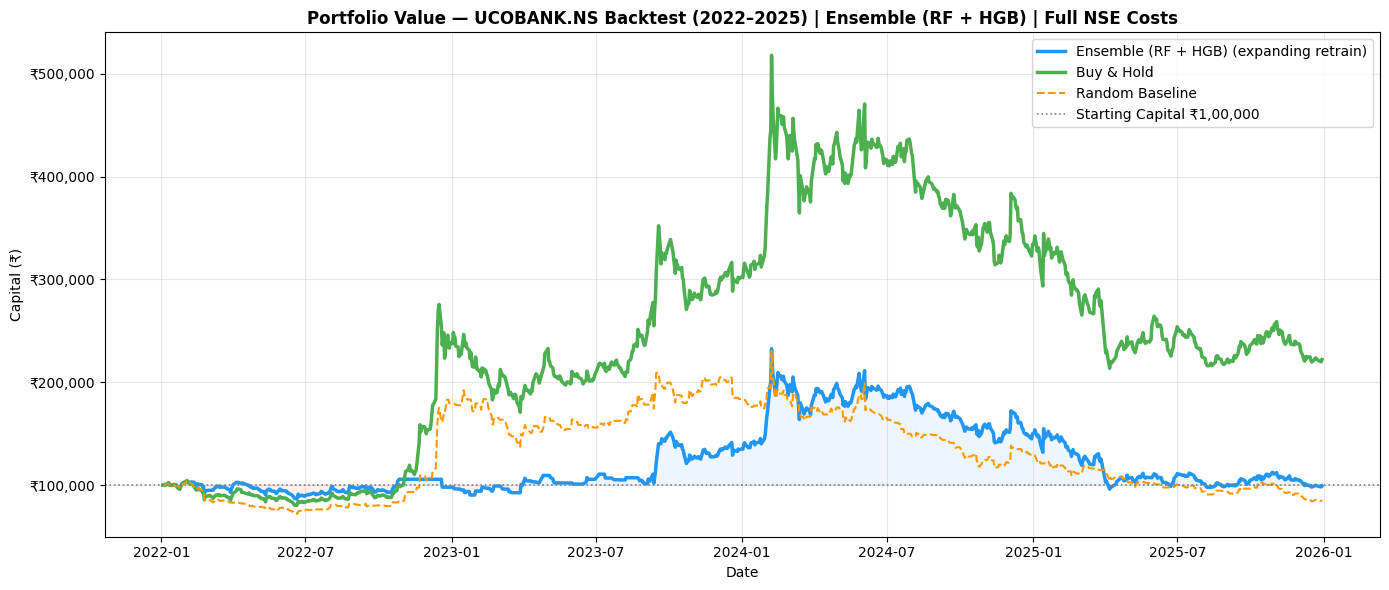

In [28]:
fig1, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(bt.index, bt['Model_Capital'],  color='#2196F3', lw=2.5, label=f'{FINAL_model_type} (expanding retrain)')
ax1.plot(bt.index, bt['BH_Capital'],     color='#4CAF50', lw=2.5, label='Buy & Hold')
ax1.plot(bt.index, bt['Random_Capital'], color='#FF9800', lw=1.5, linestyle='--', label='Random Baseline')
ax1.axhline(INITIAL_CAPITAL, color='gray', linestyle=':', lw=1.2, label='Starting Capital ₹1,00,000')
ax1.fill_between(bt.index, bt['Model_Capital'], INITIAL_CAPITAL,
                 where=(bt['Model_Capital'] >= INITIAL_CAPITAL), alpha=0.08, color='#2196F3')
ax1.fill_between(bt.index, bt['Model_Capital'], INITIAL_CAPITAL,
                 where=(bt['Model_Capital'] < INITIAL_CAPITAL), alpha=0.08, color='#F44336')
ax1.set_title(f'Portfolio Value — UCOBANK.NS Backtest (2022–2025) | {FINAL_model_type} | Full NSE Costs',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('Date'); ax1.set_ylabel('Capital (₹)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

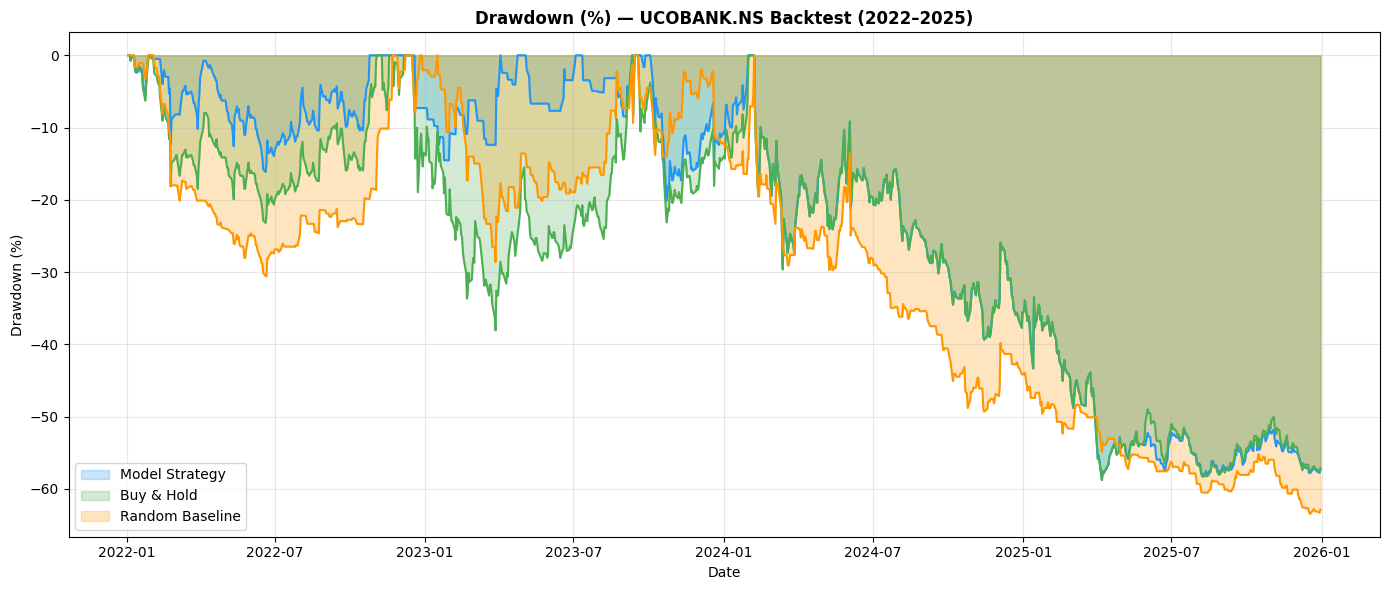

In [29]:
fig2, ax2 = plt.subplots(figsize=(14, 6))
for col, color, label in [
    ('Model_Capital', '#2196F3', 'Model Strategy'),
    ('BH_Capital',    '#4CAF50', 'Buy & Hold'),
    ('Random_Capital','#FF9800', 'Random Baseline'),
]:
    s = bt[col]; dd = (s - s.cummax()) / s.cummax() * 100
    ax2.fill_between(bt.index, dd, 0, alpha=0.25, color=color, label=label)
    ax2.plot(bt.index, dd, color=color, lw=1.5)
ax2.set_title('Drawdown (%) — UCOBANK.NS Backtest (2022–2025)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date'); ax2.set_ylabel('Drawdown (%)')
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

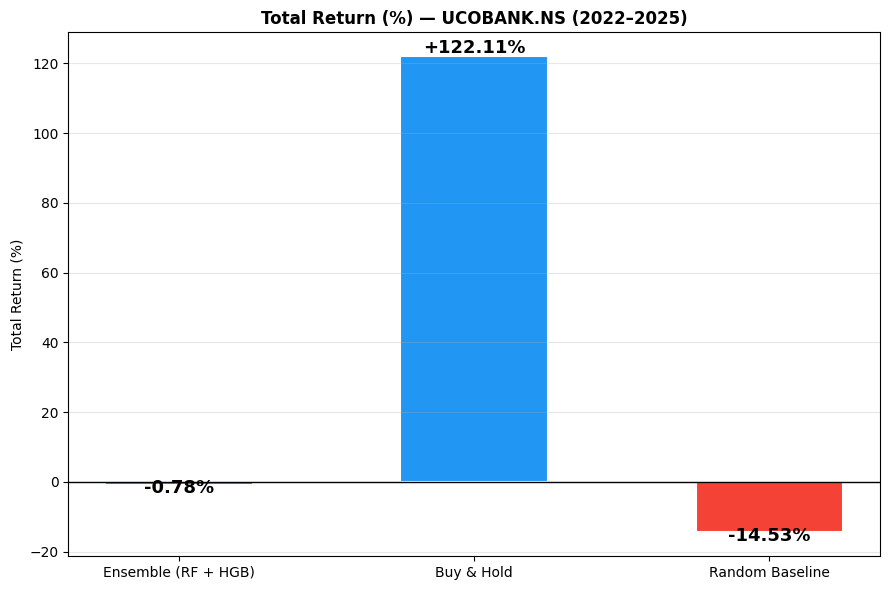

In [30]:
fig3, ax3 = plt.subplots(figsize=(9, 6))
strats   = [FINAL_model_type, 'Buy & Hold', 'Random Baseline']
ret_vals = [
    (bt['Model_Capital'].iloc[-1]  / INITIAL_CAPITAL - 1) * 100,
    (bt['BH_Capital'].iloc[-1]     / INITIAL_CAPITAL - 1) * 100,
    (bt['Random_Capital'].iloc[-1] / INITIAL_CAPITAL - 1) * 100,
]
colors_bar = ['#2196F3' if r > 0 else '#F44336' for r in ret_vals]
bars = ax3.bar(strats, ret_vals, color=colors_bar, width=0.5, edgecolor='white', linewidth=1.5)
ax3.axhline(0, color='black', lw=1)
for bar, r in zip(bars, ret_vals):
    ypos = bar.get_height() + 0.8 if r >= 0 else bar.get_height() - 2.5
    ax3.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{r:+.2f}%', ha='center', fontweight='bold', fontsize=13)
ax3.set_title('Total Return (%) — UCOBANK.NS (2022–2025)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Total Return (%)'); ax3.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

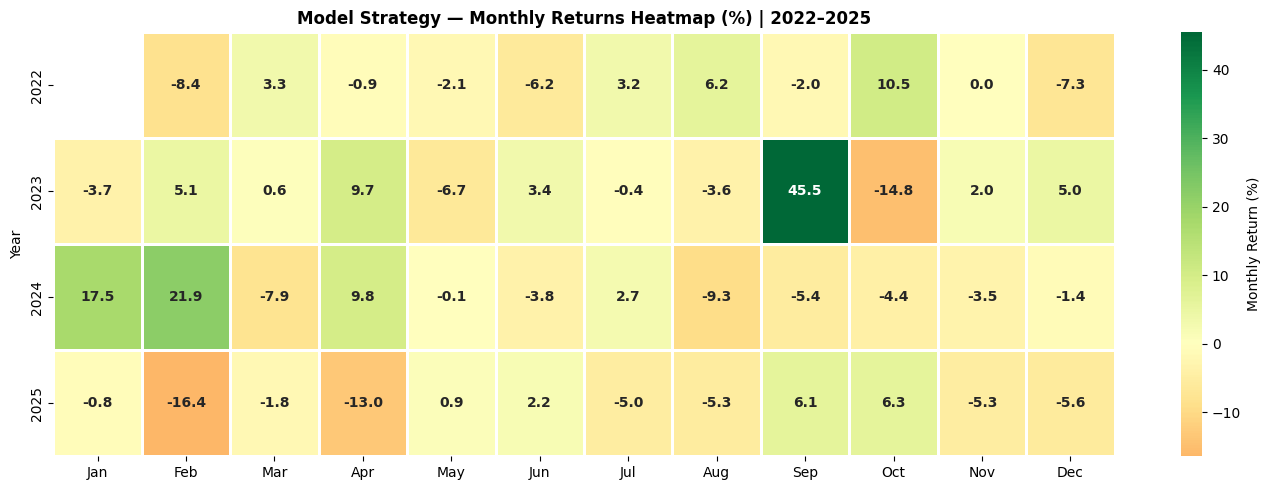


✅ Backtest complete


In [31]:
fig4, ax4 = plt.subplots(figsize=(14, 5))
monthly = bt['Model_Capital'].resample('ME').last().pct_change().dropna() * 100
monthly_df = pd.DataFrame({
    'Year' : monthly.index.year,
    'Month': monthly.index.month,
    'Ret'  : monthly.values
}).pivot(index='Year', columns='Month', values='Ret')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_df.columns = [month_names[m-1] for m in monthly_df.columns]
sns.heatmap(monthly_df, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.8, ax=ax4,
            annot_kws={'size': 10, 'fontweight': 'bold'},
            cbar_kws={'label': 'Monthly Return (%)'})
ax4.set_title('Model Strategy — Monthly Returns Heatmap (%) | 2022–2025',
              fontsize=12, fontweight='bold')
ax4.set_ylabel('Year'); ax4.set_xlabel('')
plt.tight_layout(); plt.show()
print('\n✅ Backtest complete')

## 15. Save Results

In [32]:
# ── Save results — FINAL model (Ensemble RF+HGB on impactful features) ──────
bt['Correct_Prediction'] = (bt['Signal'] == bt['Target_Return_Fwd']).astype(int)
bt['Model_Type']         = FINAL_model_type   # audit trail: which model produced signals
bt['Features_Used']      = len(FINAL_features) # audit trail: how many features

bt.to_csv('UCO_V9_backtest_daily.csv')
metrics.to_csv('UCO_V9_backtest_metrics.csv')

csv_acc = bt['Correct_Prediction'].mean()
print(f"Final model          : {FINAL_model_type}")
print(f"Features used        : {len(FINAL_features)} (impactful, data-driven)")
print(f"Threshold            : {FINAL_thresh} (tuned on val, frozen)")
print(f"CSV-verifiable acc   : {csv_acc:.4f}")
print(f"Should match bt_acc  : {bt_acc:.4f}  Match: {abs(csv_acc - bt_acc) < 0.001}")
print()
print('Backtest saved → UCO_V9_backtest_daily.csv')
print('Metrics saved  → UCO_V9_backtest_metrics.csv')


Final model          : Ensemble (RF + HGB)
Features used        : 32 (impactful, data-driven)
Threshold            : 0.4 (tuned on val, frozen)
CSV-verifiable acc   : 0.4620
Should match bt_acc  : 0.4620  Match: True

Backtest saved → UCO_V9_backtest_daily.csv
Metrics saved  → UCO_V9_backtest_metrics.csv


## 18. Summary of All Changes in This Version

| # | Change | Old behaviour | New behaviour |
|---|--------|--------------|---------------|
| 1 | OBV / PVT | Cumulative from 2010 — unbounded | 20-day rate-of-change — stationary |
| 2 | VWAP | Cumulative since 2010 — meaningless | 20-day rolling VWAP |
| 3 | Train/val/test split | 2-way split | 3-way: train 2010–2019, val 2020–2021, test 2022–2025 |
| 4 | Threshold tuning | Tuned on test set — inflated | Tuned on validation — frozen before test |
| 5 | Transaction costs | Brokerage only | Full NSE costs — ~0.3% round-trip |
| 6 | Model retraining | Static — trained once | Expanding window — retrained each year |
| 7 | CSV export | No ground-truth column | `Target_Return_Fwd` + `Correct_Prediction` + `Model_Type` |
| 8 | Calmar ratio | Not reported | Added to metrics table |
| 9 | Feature selection | Manual domain-intuition drops | Data-driven importance pruning (mean cutoff) |
| **10** | **Model & feature consistency** | **Three disconnects: HGB dead code; backtest used manual-drop features not pruned set; ensemble never reached backtest** | **Single consistent pipeline: Ensemble RF+HGB trained on `impactful_features`, threshold from val, expanding retrain in backtest — all sections use identical model and feature set. `FINAL_features`, `FINAL_thresh`, `FINAL_model_type` propagate everywhere.** |
